🛒 Online Shoppers Purchasing Intention Prediction

Full Machine Learning Pipeline

Dataset:
online_shoppers_intention.csv — Online Shoppers Purchasing Intention

Goal:
Predict whether an online shopping session will result in a purchase.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

|  # | Section                        | Description                                   |
| -: | ------------------------------ | --------------------------------------------- |
|  0 | **Setup & Libraries**          | Libraries & configuration                     |
|  1 | **Data Loading & Initial EDA** | Load data & initial exploration               |
|  2 | **Data Cleaning**              | Missing values, duplicates & data types       |
|  3 | **Preprocessing**              | Feature engineering, encoding & outliers      |
|  4 | **EDA**                        | Distributions, correlations & target analysis |
|  5 | **Split / Scale**              | Train-test split & feature scaling            |
|  6 | **Class Imbalance**            | SMOTE / SMOTETomek                            |
|  7 | **Model Training**             | LR, Decision Tree, RF & XGBoost               |
|  8 | **Evaluation**                 | Metrics, confusion matrix & ROC/PR curves     |
|  9 | **Hyperparameter Tuning**      | Cross-validation & parameter optimization     |
| 10 | **Threshold Tuning**           | Optimize classification threshold             |
| 11 | **Feature Importance**         | Identify important features                   |
| 12 | **Final Model**                | Final training & evaluation                   |
| 13 | **Save Model**                 | Save model & preprocessing                    |
| 14 | **Conclusion**                 | Results & business insights                   |


0.Setup & Libraries

In [ ]:
# ============================================
# 0. Setup & Libraries
# ============================================

# Core
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

# Preprocessing & Model Selection
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

# Imbalanced Data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Model Saving
import joblib

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


In [ ]:
# ============================================
# Download Dataset from UCI
# ============================================

import urllib.request
import zipfile

url = "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip"

zip_path = "online_shoppers_dataset.zip"

# Download dataset
urllib.request.urlretrieve(url, zip_path)

print("✅ Dataset downloaded successfully!")

✅ Dataset downloaded successfully!


In [ ]:
# Extract dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("online_shoppers_dataset")

print("✅ Dataset extracted successfully!")

✅ Dataset extracted successfully!


In [ ]:
# Check extracted files
os.listdir("online_shoppers_dataset")

['online_shoppers_intention.csv']

1. Data Loading & Initial Exploration

In [ ]:
# ============================================
# 1. Data Loading & Initial EDA
# ============================================

df = pd.read_csv(
    "online_shoppers_dataset/online_shoppers_intention.csv"
)

print("✅ Dataset loaded successfully!")

✅ Dataset loaded successfully!


In [ ]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 12330
Number of columns: 18


In [ ]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [ ]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [ ]:
print("Target Distribution:")
print(df['Revenue'].value_counts())

Target Distribution:
Revenue
False    10422
True      1908
Name: count, dtype: int64


In [ ]:
print("\nTarget Percentage:")
print(df['Revenue'].value_counts(normalize=True) * 100)


Target Percentage:
Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


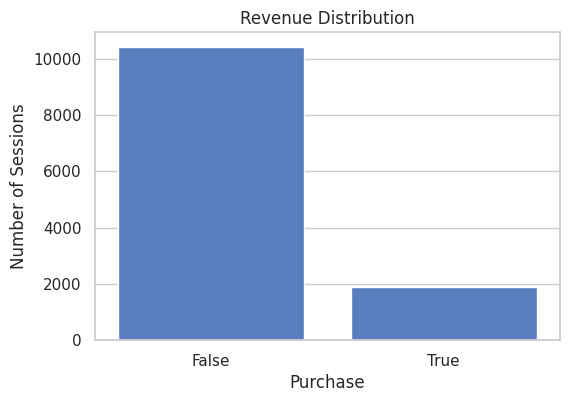

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Revenue')

plt.title('Revenue Distribution')
plt.xlabel('Purchase')
plt.ylabel('Number of Sessions')

plt.show()

In [ ]:
print("Unique values per column:")
display(df.nunique().sort_values())

Unique values per column:


,0
Revenue,2
Weekend,2
VisitorType,3
SpecialDay,6
OperatingSystems,8
Region,9
Month,10
Browser,13
Informational,17
TrafficType,20


2. Data Cleaning


2.1 Check Missing Values

We check the dataset for missing values. Missing values can affect model performance and must be identified before preprocessing.

In [ ]:
# 2.1 Check Missing Values

missing_values = df.isnull().sum()

print("Missing values per column:")
display(missing_values[missing_values > 0])

print(f"\nTotal missing values: {missing_values.sum()}")

Missing values per column:


,0



Total missing values: 0


2.2 Check Duplicate Rows

Duplicate records can introduce bias into the model. We identify and remove exact duplicate sessions.

In [ ]:
# 2.2 Check Duplicate Rows

duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 125


In [ ]:
# Display duplicate rows

if duplicate_count > 0:
    display(df[df.duplicated(keep=False)].head(10))

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
85,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
132,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
158,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
252,0,0.0,0,0.0,2,0.0,0.2,0.2,0.0,0.0,Mar,1,1,1,1,Returning_Visitor,False,False
286,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,2,2,1,1,Returning_Visitor,False,False
293,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1,1,1,1,Returning_Visitor,True,False
298,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1,1,8,1,Returning_Visitor,False,False
330,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,3,2,3,1,Returning_Visitor,False,False


In [ ]:
# Remove duplicate rows

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataset shape after removing duplicates: {df.shape}")

Dataset shape after removing duplicates: (12205, 18)


2.3 Check Data Types

We inspect the data types of all features to identify numerical, categorical, and Boolean variables before preprocessing.

In [ ]:
# 2.3 Check Data Types

print("Data types:")
display(df.dtypes)

Data types:


,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [ ]:
# Identify numerical and categorical columns

numerical_columns = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=['object', 'bool']
).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical / Boolean Columns:")
print(categorical_columns)

Numerical Columns:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Categorical / Boolean Columns:
['Month', 'VisitorType', 'Weekend', 'Revenue']


2.4 Check Invalid / Unexpected Values

We check numerical features for invalid values and categorical features for unexpected categories.

In [ ]:
# 2.4 Check Invalid Values

print("Minimum values of numerical features:")
display(df[numerical_columns].min().sort_values())

Minimum values of numerical features:


,0
Administrative,0.0
Administrative_Duration,0.0
Informational,0.0
Informational_Duration,0.0
ProductRelated,0.0
ProductRelated_Duration,0.0
BounceRates,0.0
ExitRates,0.0
PageValues,0.0
SpecialDay,0.0


In [ ]:
negative_values = (df[numerical_columns] < 0).sum()

print("Negative values:")
display(negative_values[negative_values > 0])

Negative values:


,0


In [ ]:
print("Unique values in categorical columns:\n")

for col in categorical_columns:
    print(f"{col}:")
    print(df[col].unique())
    print("-" * 40)

Unique values in categorical columns:

Month:
['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
----------------------------------------
VisitorType:
['Returning_Visitor' 'New_Visitor' 'Other']
----------------------------------------
Weekend:
[False  True]
----------------------------------------
Revenue:
[False  True]
----------------------------------------


2.5 Check Target Variable

The target variable Revenue indicates whether an online shopping session resulted in a purchase.

In [ ]:
# 2.5 Check Target Variable

print("Revenue unique values:")
print(df['Revenue'].unique())

print("\nRevenue distribution:")
print(df['Revenue'].value_counts())

Revenue unique values:
[False  True]

Revenue distribution:
Revenue
False    10297
True      1908
Name: count, dtype: int64


2.6 Final Data Cleaning Check

After cleaning, we perform a final validation to ensure that the dataset is consistent and ready for preprocessing.

In [ ]:
# 2.6 Final Data Cleaning Check

print("Final Dataset Status")
print("=" * 50)

print(f"Number of rows       : {df.shape[0]}")
print(f"Number of columns    : {df.shape[1]}")
print(f"Missing values       : {df.isnull().sum().sum()}")
print(f"Duplicate rows       : {df.duplicated().sum()}")

Final Dataset Status
Number of rows       : 12205
Number of columns    : 18
Missing values       : 0
Duplicate rows       : 0


3. Data Preprocessing

3.1 Target Variable Encoding

The target variable Revenue indicates whether an online shopping session resulted in a purchase.

Since machine learning classification models require numerical target labels, we convert the Boolean values into binary values:

False → 0 (No Purchase)

True → 1 (Purchase)

In [ ]:
# 3.1 Target Variable Encoding

df['Revenue'] = df['Revenue'].astype(int)

print("Target variable encoded successfully! ✅")
print("\nTarget distribution:")
print(df['Revenue'].value_counts())

Target variable encoded successfully! ✅

Target distribution:
Revenue
0    10297
1     1908
Name: count, dtype: int64


In [ ]:
print("Unique target values:")
print(df['Revenue'].unique())

Unique target values:
[0 1]


3.2 Feature Engineering

Feature engineering is the process of creating new meaningful features from existing variables.

In this dataset, we create features that summarize the user's browsing behavior during the session.

We create:

TotalPages: the total number of pages visited across administrative, informational, and product-related pages.
TotalDuration: the total time spent on these three types of pages.

These features provide a more general view of the user's overall engagement during the session.

In [ ]:
# 3.2 Feature Engineering

# Total number of pages visited
df['TotalPages'] = (
    df['Administrative'] +
    df['Informational'] +
    df['ProductRelated']
)

# Total time spent on different page types
df['TotalDuration'] = (
    df['Administrative_Duration'] +
    df['Informational_Duration'] +
    df['ProductRelated_Duration']
)

print("Feature engineering completed successfully! ✅")

display(
    df[['Administrative', 'Informational', 'ProductRelated',
        'TotalPages', 'TotalDuration']].head()
)

Feature engineering completed successfully! ✅


,Administrative,Informational,ProductRelated,TotalPages,TotalDuration
0,0,0,1,1,0.000000
1,0,0,2,2,64.000000
2,0,0,1,1,0.000000
3,0,0,2,2,2.666667
4,0,0,10,10,627.500000


In [ ]:
print("New features:")
print(['TotalPages', 'TotalDuration'])

print("\nNew dataset shape:")
print(df.shape)

New features:
['TotalPages', 'TotalDuration']

New dataset shape:
(12205, 20)


3.3 Categorical Feature Encoding

Machine learning models require numerical input features. Therefore, categorical variables must be converted into numerical representations.

In this dataset, Month and VisitorType are categorical features, while OperatingSystems, Browser, Region, and TrafficType are categorical variables represented by numerical codes.

We use One-Hot Encoding for these categorical features to prevent the models from interpreting category values as having a numerical order.

The Boolean Weekend feature is converted into binary values:

0 → Weekday

1 → Weekend

In [ ]:
# ============================================
# 3.3 Categorical Feature Encoding
# ============================================

# 1. تحويل Weekend من Boolean لأرقام (0 و 1) إذا كان لسه bool
if 'Weekend' in df.columns and df['Weekend'].dtype == 'bool':
    df['Weekend'] = df['Weekend'].astype(int)

# 2. حصر جميع الأعمدة الفئوية (النصية + المشفرة بأرقام)
all_categorical_features = [
    'Month',
    'VisitorType',
    'OperatingSystems',
    'Browser',
    'Region',
    'TrafficType'
]

# 3. اختيار الأعمدة الموجودة بالفعل داخل df (لتجنب KeyError لو اتعمل لبعضها تشفير قبل كده)
cols_to_encode = [col for col in all_categorical_features if col in df.columns]

# 4. تطبيق One-Hot Encoding
if cols_to_encode:
    df = pd.get_dummies(
        df,
        columns=cols_to_encode,
        drop_first=True,
        dtype=int
    )
    print(f"✅ تم تشفير الأعمدة التالية بنجاح: {cols_to_encode}")
else:
    print("ℹ️ جميع الأعمدة الفئوية مشفرة مسبقاً.")

print(f"أبعاد الداتاسيت الحالية: {df.shape}")

✅ تم تشفير الأعمدة التالية بنجاح: ['Month', 'VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
أبعاد الداتاسيت الحالية: (12205, 71)


In [ ]:
print("Dataset shape after encoding:")
print(df.shape)

print("\nNew columns:")
print(df.columns.tolist())

Dataset shape after encoding:
(12205, 71)

New columns:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Weekend', 'Revenue', 'TotalPages', 'TotalDuration', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other', 'VisitorType_Returning_Visitor', 'OperatingSystems_2', 'OperatingSystems_3', 'OperatingSystems_4', 'OperatingSystems_5', 'OperatingSystems_6', 'OperatingSystems_7', 'OperatingSystems_8', 'Browser_2', 'Browser_3', 'Browser_4', 'Browser_5', 'Browser_6', 'Browser_7', 'Browser_8', 'Browser_9', 'Browser_10', 'Browser_11', 'Browser_12', 'Browser_13', 'Region_2', 'Region_3', 'Region_4', 'Region_5', 'Region_6', 'Region_7', 'Region_8', 'Region_9', 'TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_5', 'TrafficType_6', 'TrafficType_7', 'TrafficType_8', 

In [ ]:
print("\nRemaining categorical columns:")
print(df.select_dtypes(include=['object']).columns.tolist())


Remaining categorical columns:
[]


3.4 Outlier Detection

3.4 Outlier Detection

Outliers are observations that have unusually high or low values compared with the majority of the dataset.

In this step, we identify potential outliers in the numerical features using the Interquartile Range (IQR) method.

The IQR method defines the lower and upper boundaries based on the first quartile (Q1) and third quartile (Q3). Observations outside these boundaries are considered potential outliers.

We identify the outliers first without removing them, because some extreme values may represent valid user behavior during an online shopping session.

In [ ]:
# 3.4 Outlier Detection

# Select numerical columns
numerical_columns = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# Store outlier information
outlier_summary = {}

for col in numerical_columns:

    # Calculate Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Define lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_summary[col] = outliers

# Create summary table
outlier_df = pd.DataFrame(
    list(outlier_summary.items()),
    columns=['Feature', 'Outliers']
)

# Sort by number of outliers
outlier_df = outlier_df.sort_values(
    by='Outliers',
    ascending=False
)

display(outlier_df)

,Feature,Outliers
20,Month_Nov,2982
10,Weekend,2859
8,PageValues,2730
2,Informational,2631
26,OperatingSystems_3,2530
...,...,...
39,Browser_9,1
32,Browser_2,0
25,OperatingSystems_2,0
19,Month_May,0


3.5 Low Variance Feature Detection

Variance measures how much the values of a feature vary across the dataset.

Features with very low variance contain little variation and may provide limited useful information for the machine learning models.

In this step, we calculate the variance of the numerical features to identify features with very low variability.

We inspect these features before deciding whether any of them should be removed.

In [ ]:
# 3.5 Low Variance Feature Detection

# Select numerical features
numeric_features = df.select_dtypes(
    include=['int64', 'float64']
).columns

# Calculate variance for each feature
variance_df = pd.DataFrame({
    'Feature': numeric_features,
    'Variance': [df[col].var() for col in numeric_features]
})

# Sort by variance
variance_df = variance_df.sort_values(
    by='Variance',
    ascending=True
)

display(variance_df)

,Feature,Variance
67,TrafficType_17,8.193363e-05
39,Browser_9,8.193363e-05
62,TrafficType_12,8.193363e-05
66,TrafficType_16,2.457606e-04
28,OperatingSystems_5,4.914004e-04
...,...,...
12,TotalPages,2.174108e+03
3,Informational_Duration,2.000098e+04
1,Administrative_Duration,3.150336e+04
5,ProductRelated_Duration,3.684870e+06


3.6 Final Preprocessing Check

3.6 Final Preprocessing Check

After completing the preprocessing steps, we perform a final check of the dataset to ensure that the data is properly structured and ready for exploratory data analysis.

We verify the dataset dimensions, data types, missing values, and the first few records.

In [ ]:
# 3.6 Final Preprocessing Check

print("Final Preprocessing Status")
print("=" * 50)

print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

print(f"\nTotal missing values: {df.isnull().sum().sum()}")

print("\nData Types:")
display(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Final Preprocessing Status
Number of rows    : 12205
Number of columns : 71

Total missing values: 0

Data Types:


,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
...,...
TrafficType_16,int64
TrafficType_17,int64
TrafficType_18,int64
TrafficType_19,int64



First 5 Rows:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_11,TrafficType_12,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


4. Exploratory Data Analysis

4.1 Target Variable Distribution

The target variable Revenue indicates whether an online shopping session resulted in a purchase.

In this step, we analyze the distribution of the target classes to understand the proportion of sessions that resulted in a purchase compared with sessions that did not.

Understanding the target distribution is important because an imbalanced target can affect the performance and evaluation of classification models.

In [ ]:
# 4.1 Target Variable Distribution

# Count target classes
revenue_counts = df['Revenue'].value_counts().sort_index()

print("Revenue Distribution:")
print(revenue_counts)

Revenue Distribution:
Revenue
0    10297
1     1908
Name: count, dtype: int64


In [ ]:
# Calculate percentages

revenue_percentage = (
    df['Revenue']
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("Revenue Percentage:")
print(revenue_percentage)

Revenue Percentage:
Revenue
0    84.367063
1    15.632937
Name: proportion, dtype: float64


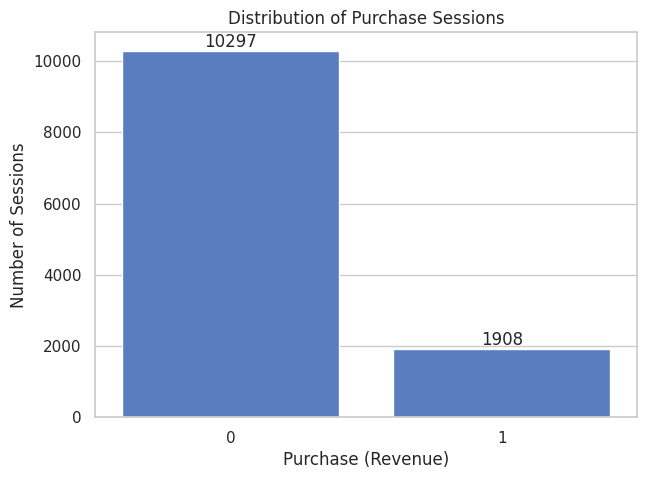

In [ ]:
# Plot target distribution

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x='Revenue'
)

plt.title('Distribution of Purchase Sessions')
plt.xlabel('Purchase (Revenue)')
plt.ylabel('Number of Sessions')

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

4.2 Numerical Features Distribution

In this step, we analyze the distributions of the numerical features to understand the browsing behavior of online shoppers.

We use histograms and kernel density estimates (KDE) to examine the spread, concentration, and skewness of the numerical variables.

This analysis can also help identify features with highly skewed distributions or extreme values that may require further consideration during modeling.

In [ ]:
# 4.2 Numerical Features Distribution

numerical_features = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay',
    'TotalPages',
    'TotalDuration'
]

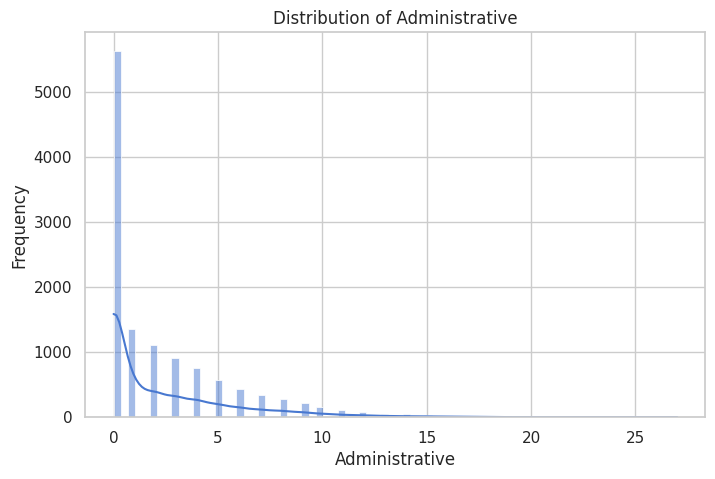

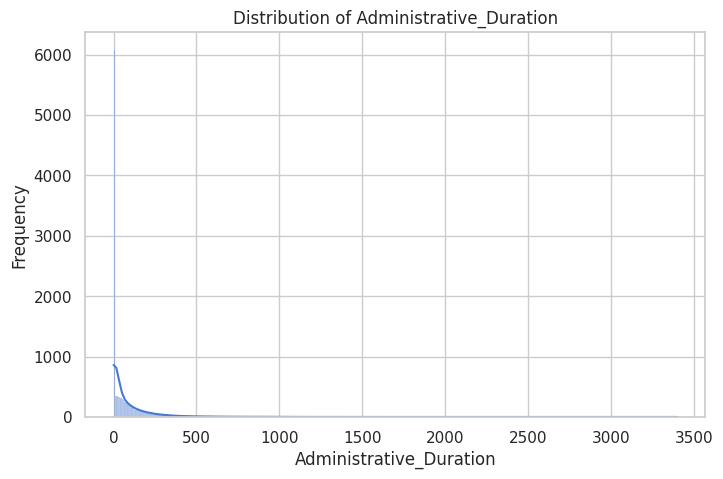

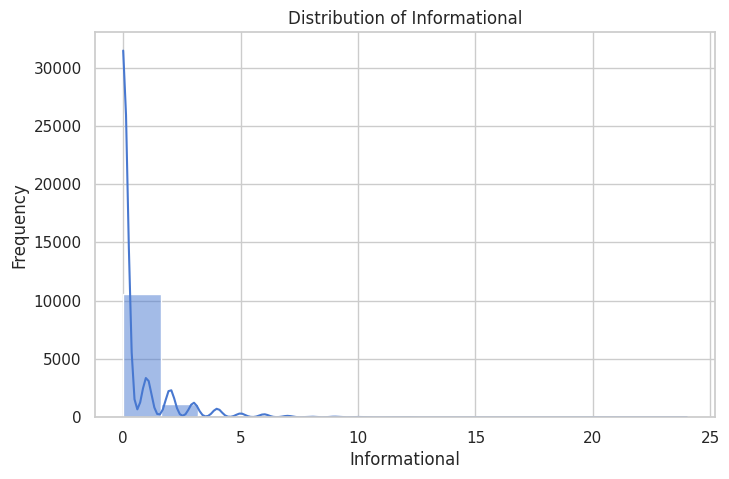

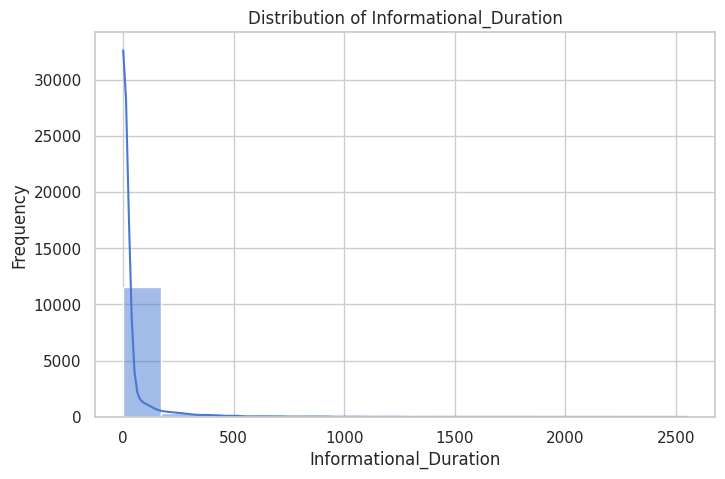

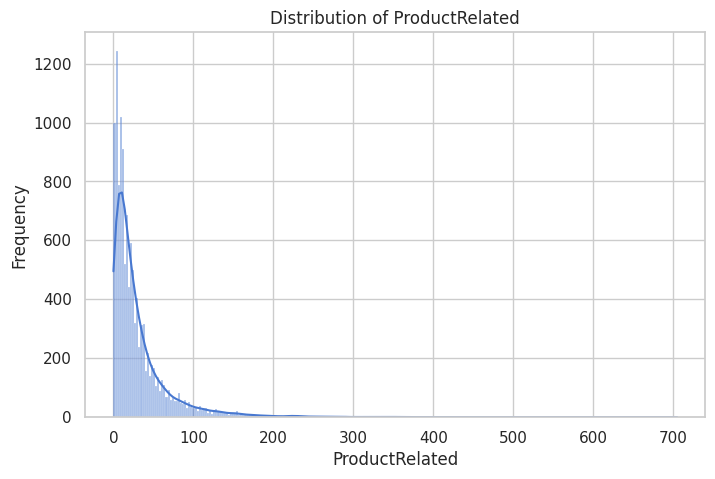

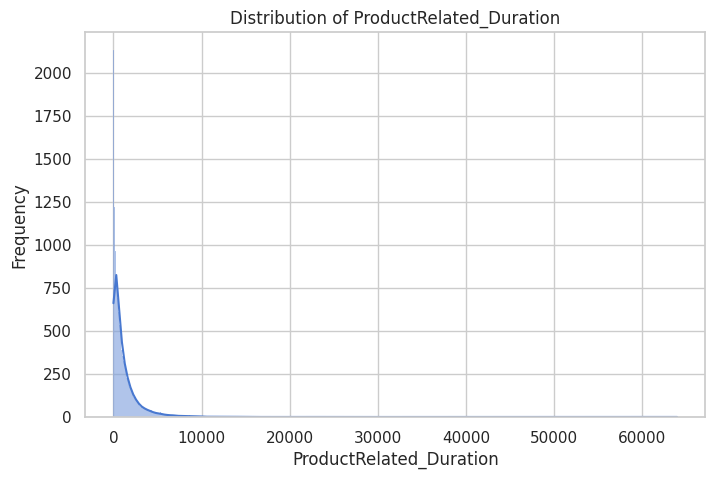

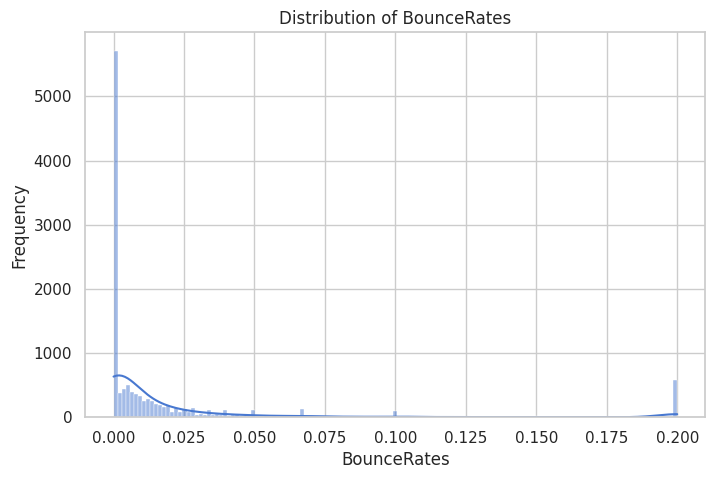

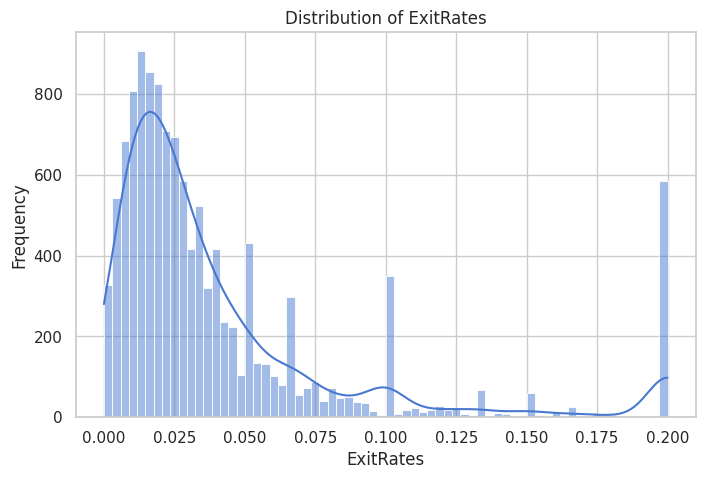

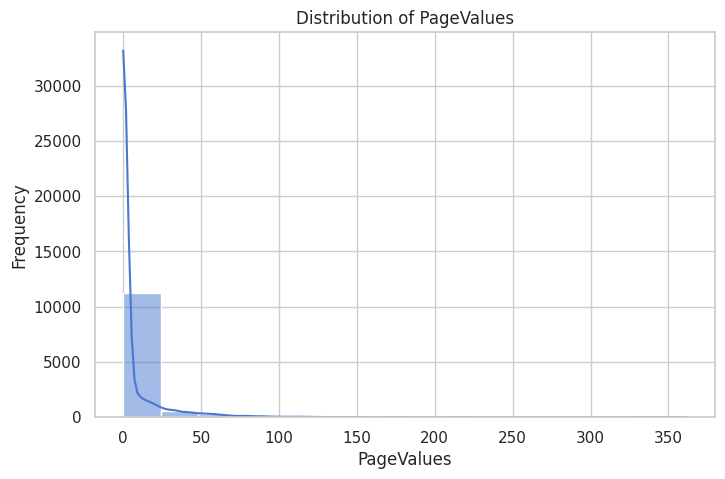

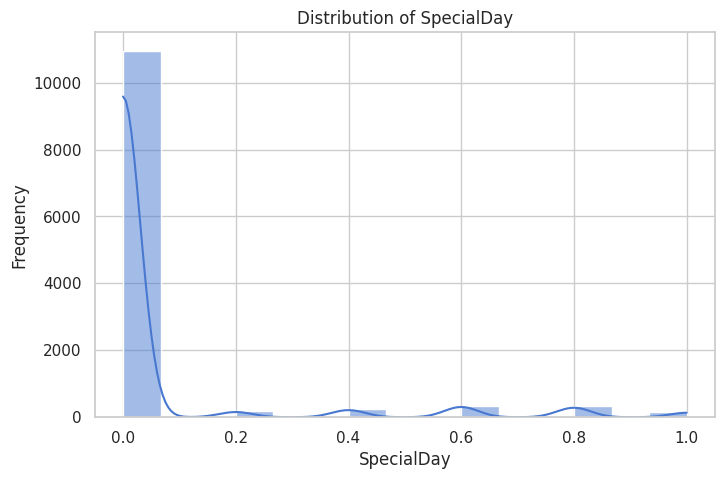

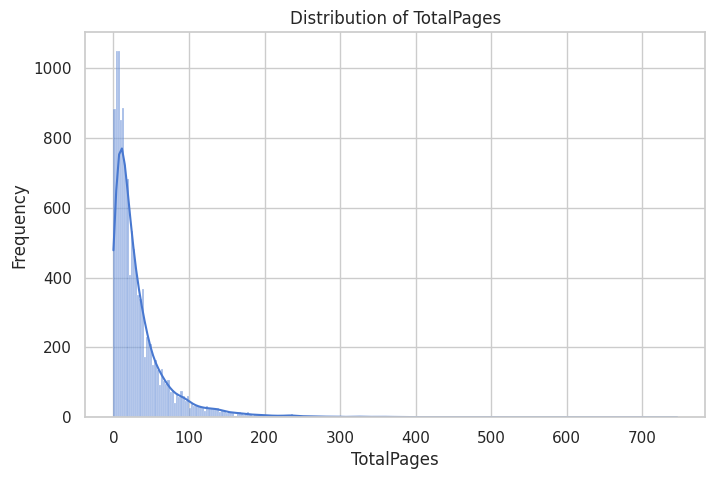

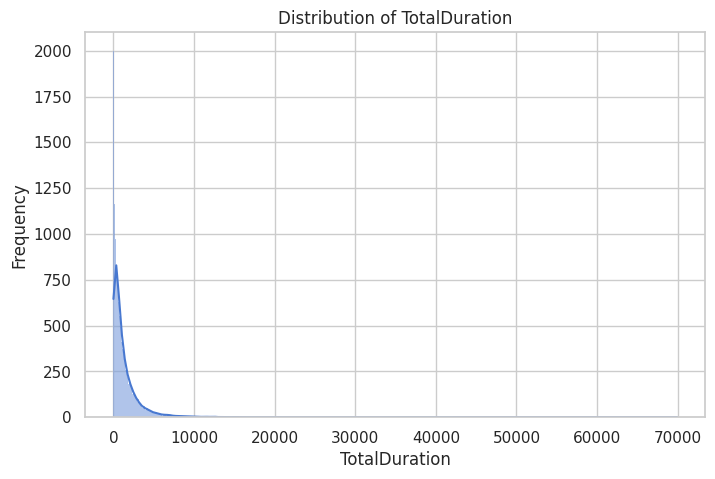

In [ ]:
# Plot distributions

for feature in numerical_features:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=feature,
        kde=True
    )

    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    plt.show()

4.3 Numerical Features vs Revenue

In this step, we analyze the relationship between numerical features and the target variable Revenue.

We compare the distributions of numerical features between sessions that resulted in a purchase and sessions that did not.

Box plots are used to identify differences in the distributions and to observe potential outliers across the two target classes.

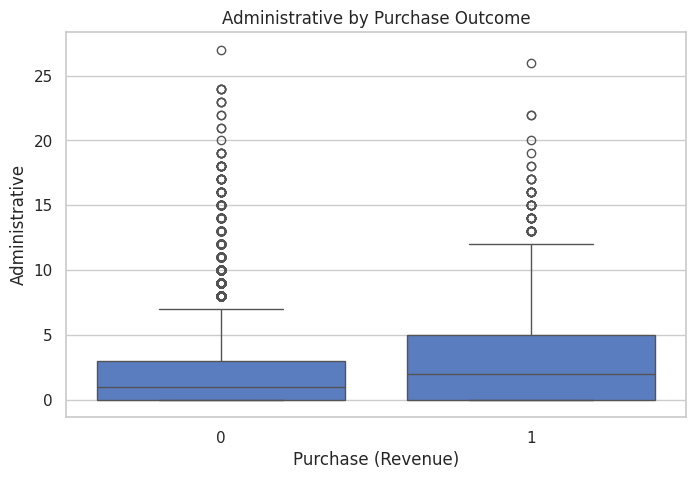

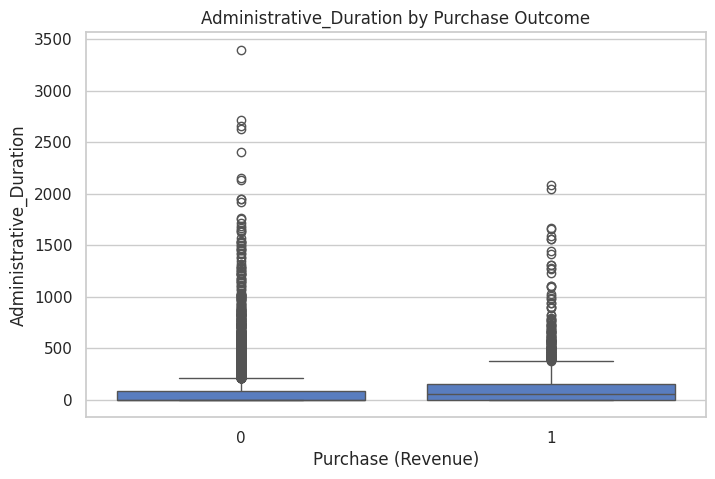

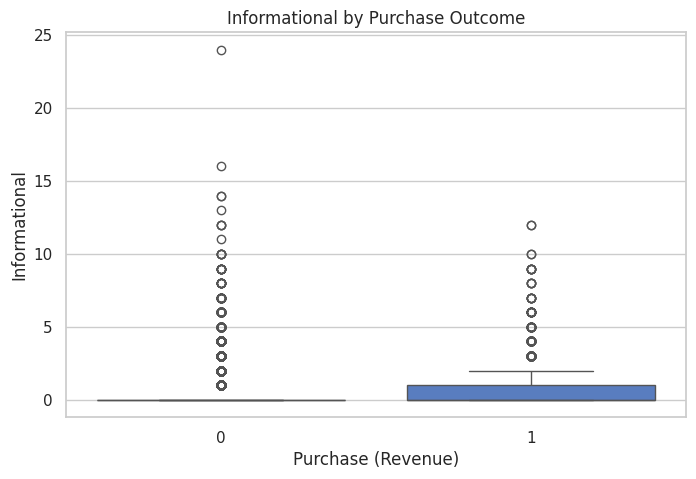

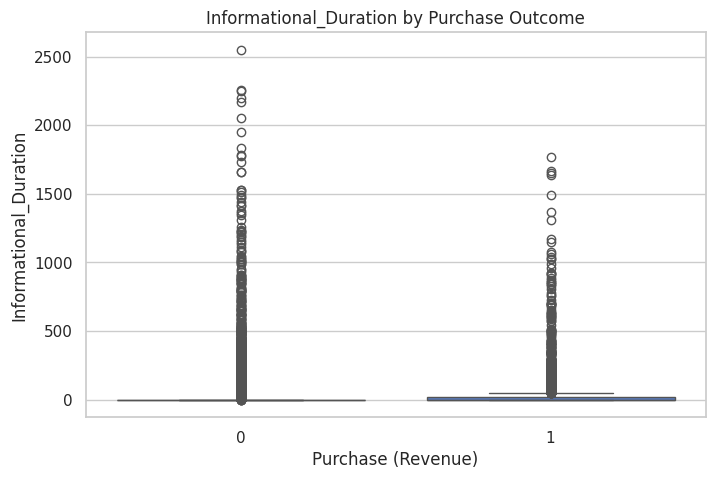

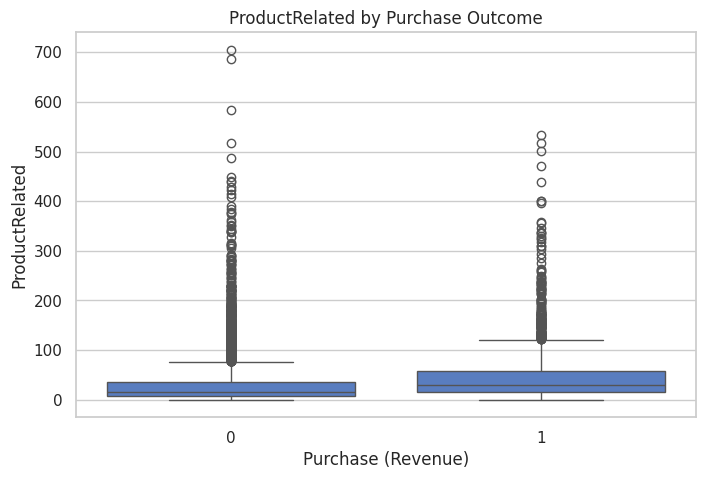

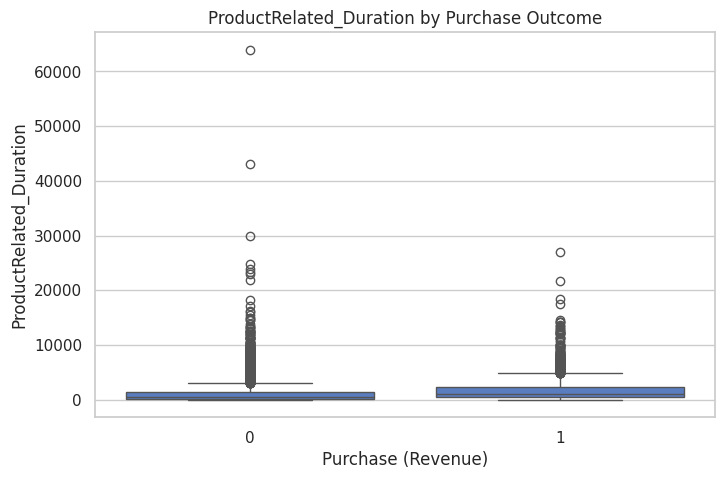

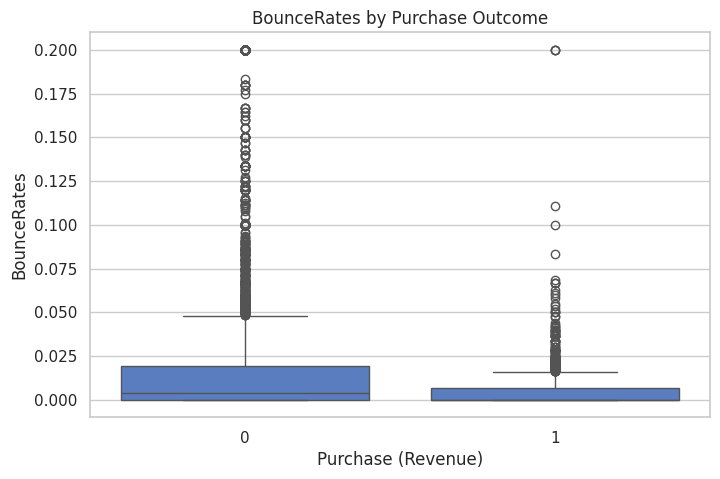

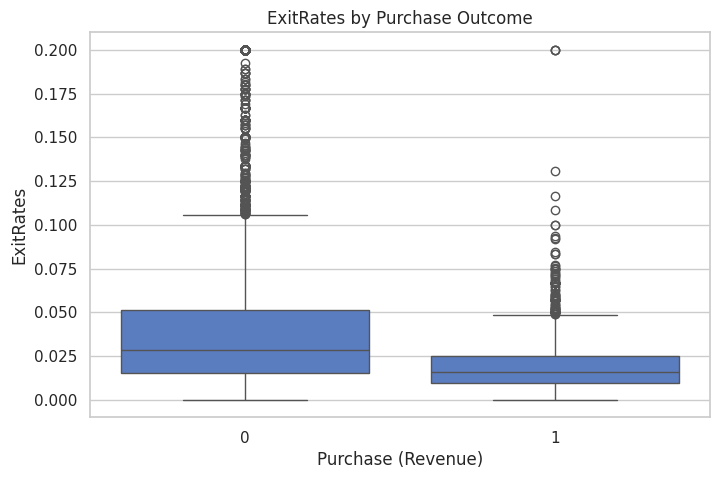

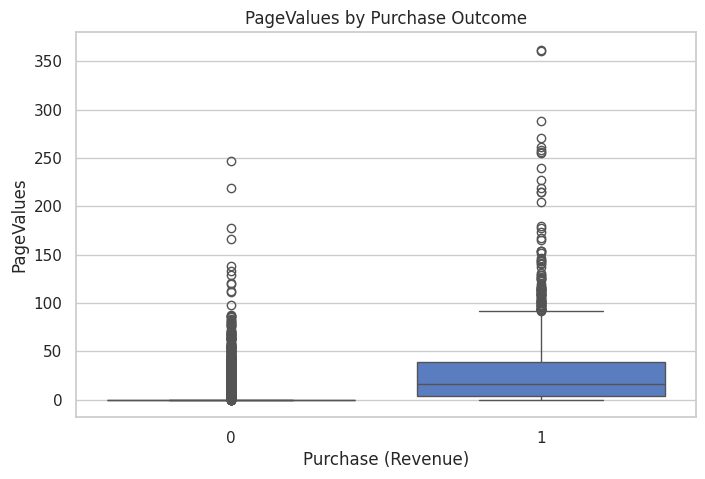

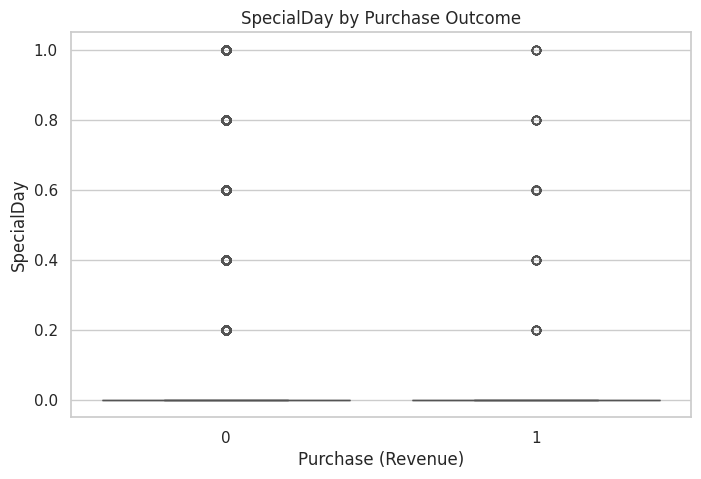

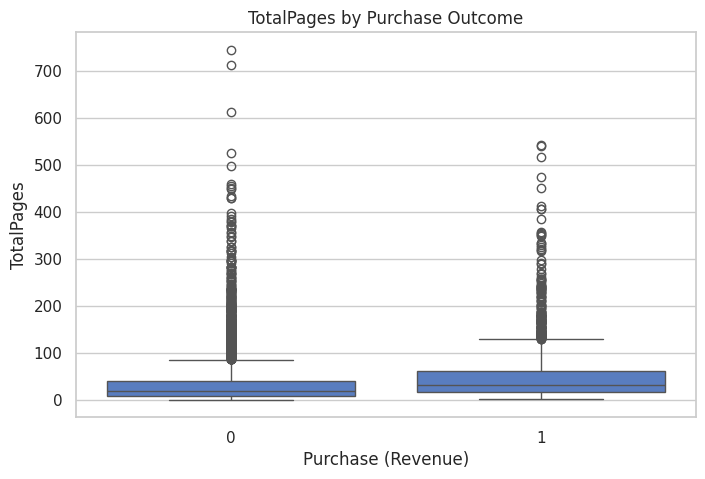

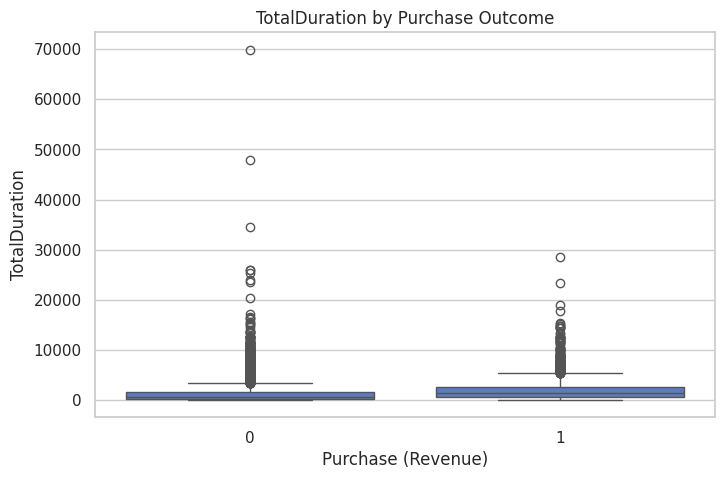

In [ ]:
# 4.3 Numerical Features vs Revenue

for feature in numerical_features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x='Revenue',
        y=feature
    )

    plt.title(f'{feature} by Purchase Outcome')
    plt.xlabel('Purchase (Revenue)')
    plt.ylabel(feature)

    plt.show()

4.4 Categorical Features Analysis

In this step, we analyze the categorical and discrete features to understand how different user groups and browsing characteristics are associated with purchase behavior.

We compare the purchase rate across different categories to identify groups with higher or lower purchasing activity.

This analysis helps us understand which categorical features may provide useful information for predicting online purchases.

In [ ]:
# 4.4 Categorical Features Analysis

encoded_categorical_groups = {
    'OperatingSystems': [
        col for col in df.columns
        if col.startswith('OperatingSystems_')
    ],

    'Browser': [
        col for col in df.columns
        if col.startswith('Browser_')
    ],

    'Region': [
        col for col in df.columns
        if col.startswith('Region_')
    ],

    'TrafficType': [
        col for col in df.columns
        if col.startswith('TrafficType_')
    ]
}

for feature, columns in encoded_categorical_groups.items():

    purchase_rates = {}

    for col in columns:
        category_sessions = df[df[col] == 1]

        if len(category_sessions) > 0:
            purchase_rates[col] = (
                category_sessions['Revenue'].mean() * 100
            )

    purchase_rate_df = pd.DataFrame(
        list(purchase_rates.items()),
        columns=['Category', 'Purchase Rate (%)']
    ).sort_values(
        by='Purchase Rate (%)',
        ascending=False
    )

    print(f"\nPurchase Rate by {feature}:")
    display(purchase_rate_df)


Purchase Rate by OperatingSystems:


,Category,Purchase Rate (%)
6,OperatingSystems_8,22.666667
2,OperatingSystems_4,17.782427
0,OperatingSystems_2,17.657850
3,OperatingSystems_5,16.666667
5,OperatingSystems_7,14.285714
1,OperatingSystems_3,10.592885
4,OperatingSystems_6,10.526316



Purchase Rate by Browser:


,Category,Purchase Rate (%)
10,Browser_12,30.000000
11,Browser_13,28.571429
8,Browser_10,19.631902
3,Browser_5,18.494624
2,Browser_4,17.783858
9,Browser_11,16.666667
6,Browser_8,15.555556
0,Browser_2,15.514398
5,Browser_7,12.244898
4,Browser_6,11.494253



Purchase Rate by Region:


,Category,Purchase Rate (%)
7,Region_9,17.029703
0,Region_2,16.666667
3,Region_5,16.352201
5,Region_7,15.699208
2,Region_4,14.944492
1,Region_3,14.670029
4,Region_6,13.982522
6,Region_8,12.993039



Purchase Rate by TrafficType:


,Category,Purchase Rate (%)
14,TrafficType_16,33.333333
5,TrafficType_7,30.000000
6,TrafficType_8,27.696793
18,TrafficType_20,25.906736
0,TrafficType_2,21.656865
3,TrafficType_5,21.538462
8,TrafficType_10,20.000000
9,TrafficType_11,19.028340
2,TrafficType_4,15.478424
12,TrafficType_14,15.384615


4.5 Correlation Analysis

Correlation analysis is used to measure the strength and direction of the relationship between numerical features.

In this step, we calculate the correlation matrix and visualize it using a heatmap.

This helps us identify features that are strongly related to each other and understand their relationship with the target variable Revenue.

Highly correlated features may contain similar information and can be considered during feature selection and model development.

In [ ]:
# 4.5 Correlation Analysis

correlation_features = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay',
    'Weekend',
    'TotalPages',
    'TotalDuration',
    'Revenue'
]

correlation_matrix = df[correlation_features].corr()

print("Correlation with Revenue:")
display(
    correlation_matrix['Revenue']
    .sort_values(ascending=False)
    .to_frame('Correlation')
)

Correlation with Revenue:


,Correlation
Revenue,1.000000
PageValues,0.491894
TotalPages,0.161535
ProductRelated,0.156042
TotalDuration,0.153720
ProductRelated_Duration,0.150077
Administrative,0.136330
Informational,0.093626
Administrative_Duration,0.091768
Informational_Duration,0.069358


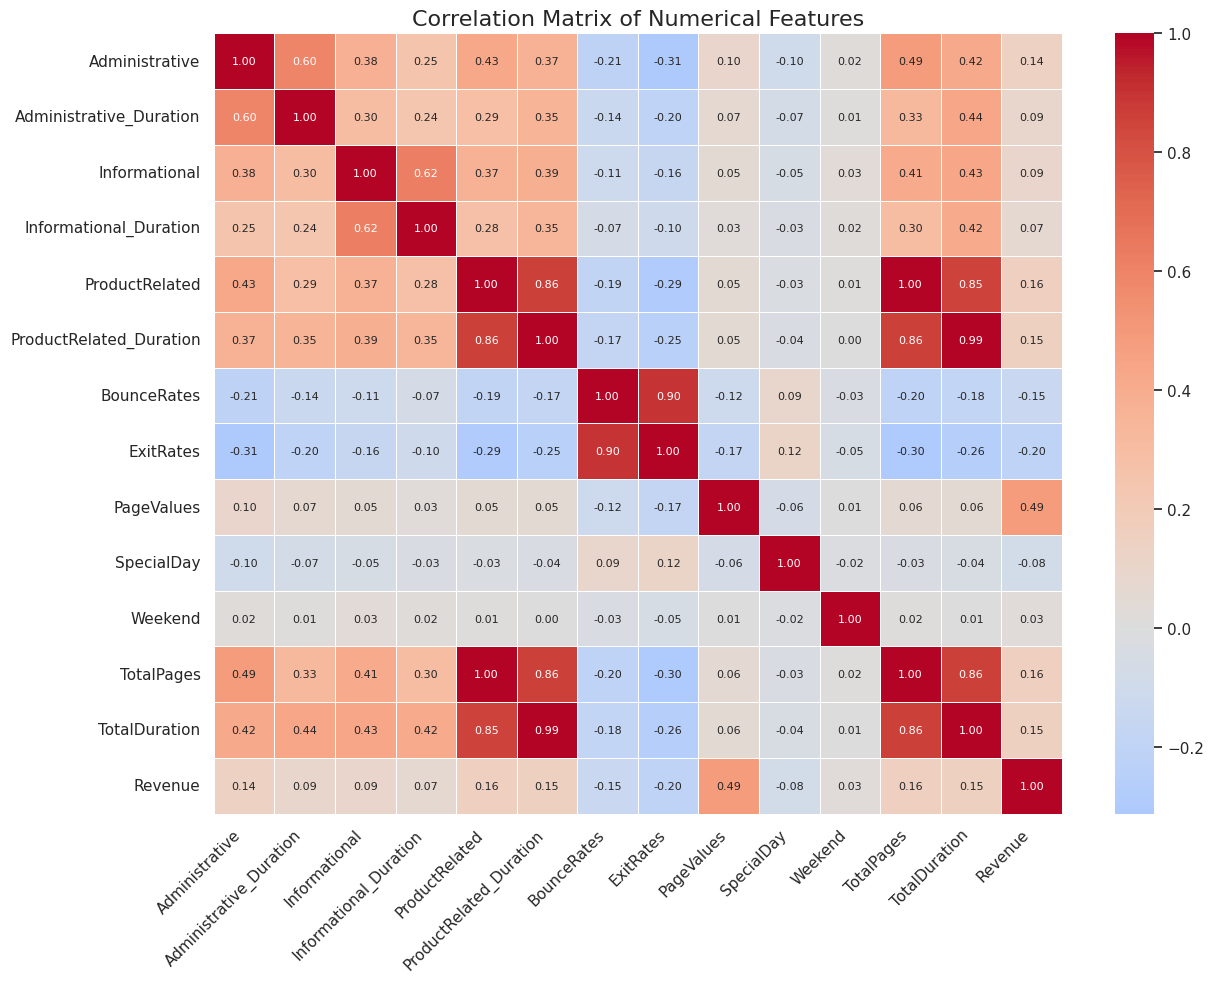

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(13, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)

plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

4.6 Purchase Rate Analysis

In this step, we analyze the purchase rate across different categorical and discrete features.

The purchase rate represents the percentage of online shopping sessions that resulted in a purchase within each category.

This analysis helps us identify categories and user characteristics that are associated with higher or lower purchasing activity.

In [ ]:
# 1. إزالة المسافات وتجهيز خريطة بأسماء الأعمدة
df.columns = df.columns.str.strip()
cols_lookup = {col.lower(): col for col in df.columns}

# 2. القائمة المطلوبة
purchase_rate_features = [
    'OperatingSystems',
    'Browser',
    'Region',
    'TrafficType'
]

# 3. التأكد من مطابقة الأسماء تلقائياً مهما كانت حالة الأحرف
valid_features = [cols_lookup[f.lower()] for f in purchase_rate_features if f.lower() in cols_lookup]

# 4. حساب وعرض نسبة الشراء
for feature in valid_features:
    purchase_rate = (
        df.groupby(feature)['Revenue']
        .mean()
        .sort_values(ascending=False) * 100
    )

    print(f"\nPurchase Rate by {feature}:")
    display(purchase_rate.to_frame('Purchase Rate (%)'))

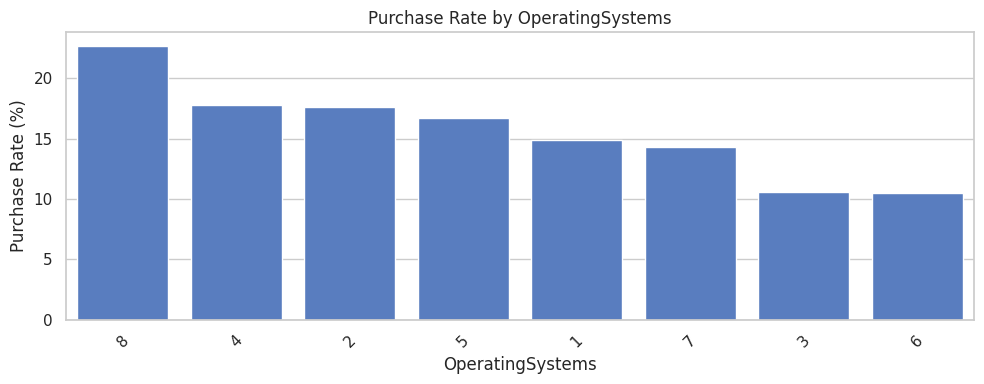

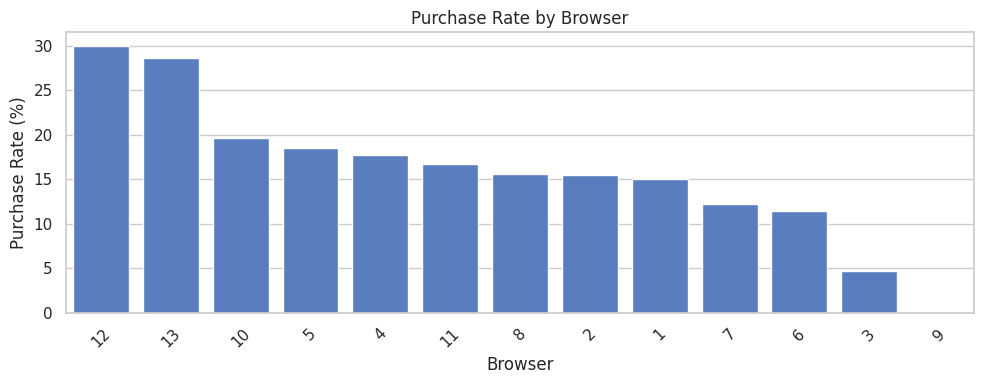

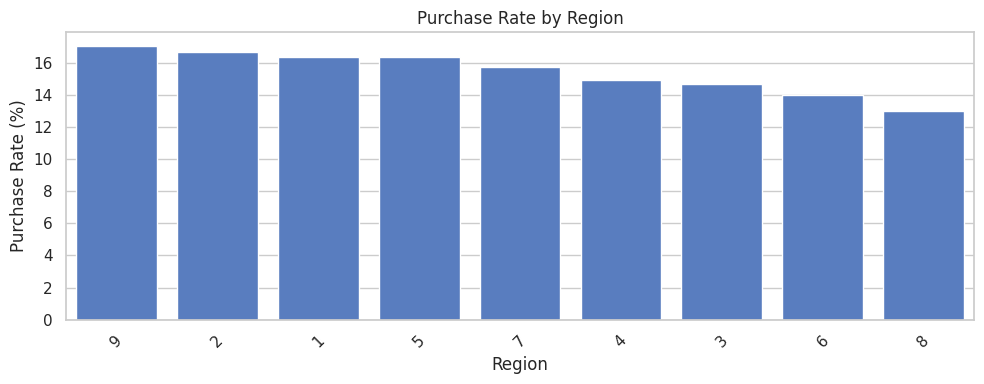

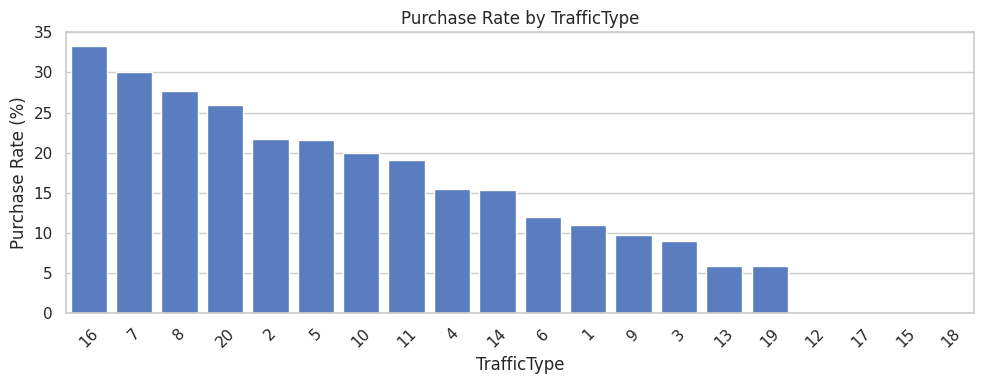

In [ ]:
# المجموعات المراد حساب نسب الشراء لها
feature_groups = ['OperatingSystems', 'Browser', 'Region', 'TrafficType']

for group in feature_groups:
    # جمع أعمدة التصنيف المشتقة
    cols = [c for c in df.columns if c.startswith(group + '_')]

    if not cols:
        continue

    # استرجاع الفئة الأصلية (القيمة 1 تكون الفئة الأساسية، وباقي الأرقام من اسم العمود)
    category_series = df[cols].idxmax(axis=1).str.replace(f"{group}_", "")
    category_series = category_series.where(df[cols].sum(axis=1) == 1, '1')

    # حساب نسبة الشراء
    purchase_rate = (
        df.groupby(category_series)['Revenue']
        .mean()
        .sort_values(ascending=False) * 100
    )

    # رسم المخطط البياني
    plt.figure(figsize=(10, 4))
    sns.barplot(x=purchase_rate.index, y=purchase_rate.values)
    plt.title(f'Purchase Rate by {group}')
    plt.xlabel(group)
    plt.ylabel('Purchase Rate (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Section 5 — Train-Test Split & Scaling.

5.1 Separate Features and Target

5.1 Separating Features and Target

Before training the machine learning models, we separate the dataset into input features X and the target variable y.

The features contain the information used by the models to make predictions, while Revenue is the target variable that we want to predict.

In [ ]:
# 5.1 Separate Features and Target

X = df.drop('Revenue', axis=1)
y = df['Revenue']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (12205, 70)
Target shape: (12205,)


5.2 Train-Test Split

We split the dataset into training and testing sets.

The training set is used to train the machine learning models, while the testing set is kept separate and used to evaluate their performance on unseen data.

Stratified splitting is used to preserve the same proportion of purchase and non-purchase sessions in both sets.

In [ ]:
# 5.2 Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (9764, 70)
Testing set : (2441, 70)

Training target distribution:
Revenue
0    0.843712
1    0.156288
Name: proportion, dtype: float64

Testing target distribution:
Revenue
0    0.843507
1    0.156493
Name: proportion, dtype: float64


5.3 Feature Scaling

Feature scaling is used to bring numerical features to a comparable scale.

We use StandardScaler, which standardizes features based on their mean and standard deviation.

The scaler is fitted only on the training data and then applied to both the training and testing data. This prevents data leakage from the test set.

In [ ]:
# 5.3 Feature Scaling

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully! ✅")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape :", X_test_scaled.shape)

Feature scaling completed successfully! ✅
Training data shape: (9764, 70)
Testing data shape : (2441, 70)


# 6. Handling Class Imbalance (SMOTE)

In this dataset, the target variable `Revenue` is imbalanced, as only approximately 15.5% of the total sessions resulted in a purchase.

Imbalanced datasets can lead classification models to become biased toward the majority class (No Purchase), resulting in high overall accuracy but poor recall and detection of actual purchase events.

To address this issue, we apply the **Synthetic Minority Over-sampling Technique (SMOTE)**:
- SMOTE synthesizes new examples for the minority class along the line segments joining any/all of the k-nearest neighbors.
- It is fitted exclusively on the training set (`X_train_scaled`, `y_train`) to prevent any data leakage into the evaluation phase.
- The test set remains untouched to reflect the real-world distribution of shopping sessions.

In [ ]:
# ============================================
# 6. Handling Class Imbalance
# ============================================

from imblearn.over_sampling import SMOTE

# 6.1 Check class distribution before SMOTE
print("Target distribution in training data before SMOTE:")
print(pd.Series(y_train).value_counts())
print("\nTarget percentage before SMOTE:")
print(pd.Series(y_train).value_counts(normalize=True) * 100)

# 6.2 Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\n" + "=" * 50)
print("SMOTE applied successfully! ✅")
print(f"X_train shape before SMOTE : {X_train_scaled.shape}")
print(f"X_train shape after SMOTE  : {X_train_resampled.shape}")

print("\nTarget distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Target distribution in training data before SMOTE:
Revenue
0    8238
1    1526
Name: count, dtype: int64

Target percentage before SMOTE:
Revenue
0    84.371159
1    15.628841
Name: proportion, dtype: float64

SMOTE applied successfully! ✅
X_train shape before SMOTE : (9764, 70)
X_train shape after SMOTE  : (16476, 70)

Target distribution after SMOTE:
Revenue
1    8238
0    8238
Name: count, dtype: int64


# 7. Model Training

In this section, we train multiple supervised machine learning classification algorithms on the balanced training dataset to compare their learning capability and decision boundaries:

1. **Logistic Regression:** Serves as a linear baseline model to assess linear separability between classes.
2. **Decision Tree Classifier:** Captures non-linear relationships and interactions without assuming feature distributions.
3. **Random Forest Classifier:** An ensemble bagging method that builds multiple decision trees to reduce variance and mitigate overfitting.
4. **XGBoost Classifier:** A gradient-boosting framework that sequentially builds trees, optimizing performance on challenging instances.

All models are trained on the resampled training data (`X_train_resampled`, `y_train_resampled`).

In [ ]:
# ============================================
# 7. Model Training
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 7.1 Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

# 7.2 Train all models on resampled data
trained_models = {}

print("Training Models...")
print("=" * 50)

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model
    print(f"✅ {name} trained successfully!")

print("\nAll models trained successfully! ✅")

Training Models...
✅ Logistic Regression trained successfully!
✅ Decision Tree trained successfully!
✅ Random Forest trained successfully!
✅ XGBoost trained successfully!

All models trained successfully! ✅


# 8. Model Evaluation

Evaluating models on imbalanced classification tasks requires metrics beyond simple classification accuracy, as high accuracy can be achieved simply by predicting the majority class.

We evaluate all trained models on the unseen, scaled test set (`X_test_scaled`, `y_test`) using the following metrics:

- **Accuracy:** The overall ratio of correct predictions to total predictions.
- **Precision:** The proportion of predicted purchases that were actual purchases (minimizing false positives).
- **Recall (Sensitivity):** The proportion of actual purchases that the model successfully identified (minimizing false negatives).
- **F1-Score:** The harmonic mean of precision and recall, serving as our primary benchmark for balanced model performance.
- **ROC-AUC Score:** The area under the Receiver Operating Characteristic curve, measuring the model's ability to distinguish between classes across varying thresholds.

8.1 Evaluation Metrics

In this step, we evaluate the performance of the trained machine learning models on the unseen test set.

We use several classification metrics, including Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

Since the dataset is imbalanced, Accuracy alone may not provide a complete picture of model performance. Therefore, Precision, Recall, F1-Score, and ROC-AUC are also considered when comparing the models.

In [ ]:
# 8.1 Evaluation Metrics

evaluation_results = []

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Probability predictions for ROC-AUC
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    evaluation_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

# Create comparison DataFrame
evaluation_df = pd.DataFrame(evaluation_results)

# Sort by F1-Score
evaluation_df = evaluation_df.sort_values(
    by='F1-Score',
    ascending=False
).reset_index(drop=True)

display(evaluation_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.892257,0.639344,0.714660,0.674907,0.919280
1,XGBoost,0.893486,0.659686,0.659686,0.659686,0.926279
2,Logistic Regression,0.859484,0.535390,0.772251,0.632369,0.908093
3,Decision Tree,0.851700,0.520325,0.670157,0.585812,0.777769


8.2 Confusion Matrix

The confusion matrix provides a detailed view of the classification performance of each machine learning model. Unlike accuracy and other summary metrics, the confusion matrix shows how the model's predictions are distributed across the two classes: Purchase and No Purchase.

It consists of four important components:

True Negative (TN): The model correctly predicts that a session will not result in a purchase.
True Positive (TP): The model correctly predicts that a session will result in a purchase.
False Positive (FP): The model predicts a purchase, but the actual outcome is no purchase.
False Negative (FN): The model predicts no purchase, but the actual outcome is a purchase.

Analyzing these values helps us understand the types of mistakes made by each model. This is particularly important for the Online Shoppers Purchasing Intention dataset because the target classes are imbalanced and correctly identifying purchasing sessions is an important business objective.

In this step, we generate a separate confusion matrix for each trained model using the unseen test set. The results will help us compare the models beyond their overall accuracy and understand their ability to identify actual purchasing sessions.

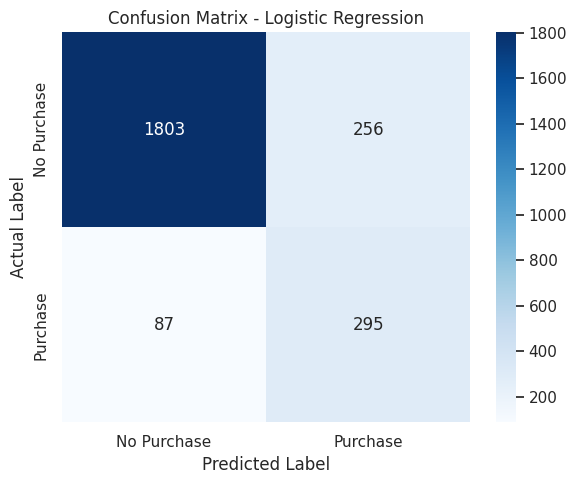

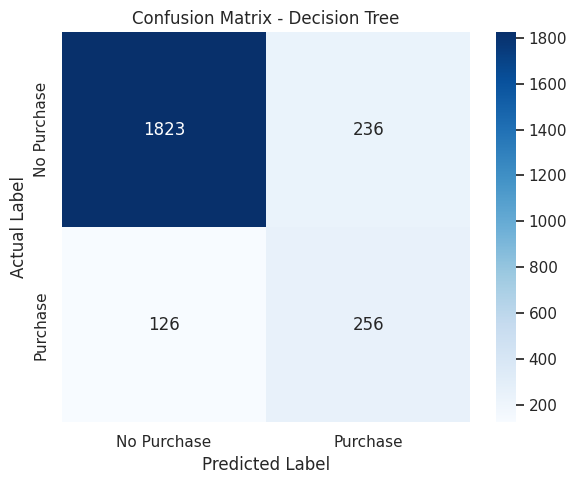

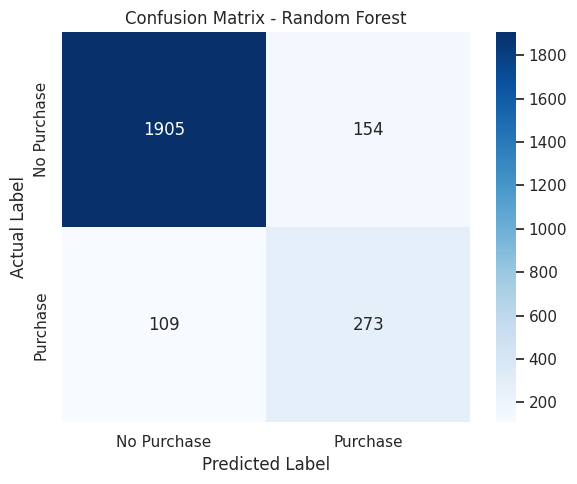

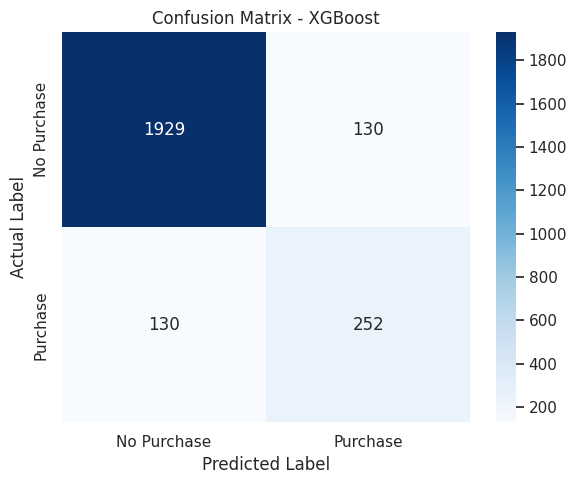

In [ ]:
# 8.2 Confusion Matrix

for name, model in models.items():

    # Generate predictions on the test set
    y_pred = model.predict(X_test_scaled)

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No Purchase', 'Purchase'],
        yticklabels=['No Purchase', 'Purchase']
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')

    plt.tight_layout()
    plt.show()

8.3 ROC Curve

The Receiver Operating Characteristic (ROC) curve is used to evaluate the ability of a classification model to distinguish between the two target classes: Purchase and No Purchase.

The ROC curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at different classification thresholds.

The True Positive Rate represents the proportion of actual purchasing sessions that are correctly identified by the model, while the False Positive Rate represents the proportion of non-purchasing sessions that are incorrectly classified as purchases.

The Area Under the ROC Curve (ROC-AUC) summarizes the overall ability of the model to discriminate between the two classes. A higher ROC-AUC indicates better discrimination performance.

In this step, we plot the ROC curves for all four trained models on the same figure. This allows us to visually compare their classification performance across different probability thresholds.

The ROC curves are generated using the predicted probabilities from the unseen test set rather than the final class predictions. This provides a more complete evaluation of how each model behaves when the classification threshold changes.

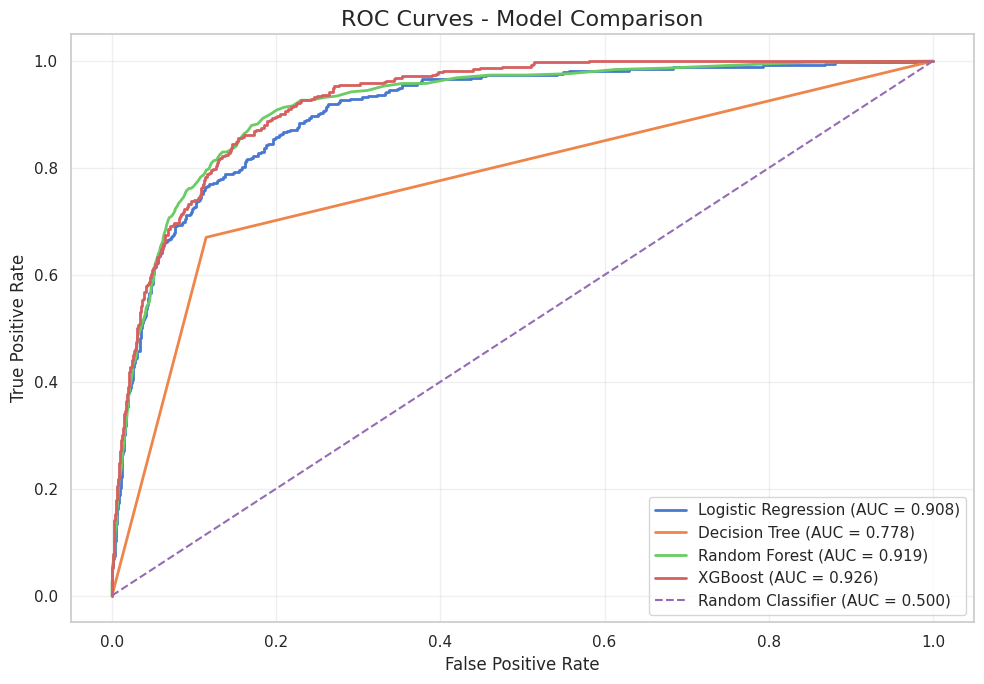

In [ ]:
# 8.3 ROC Curve

plt.figure(figsize=(10, 7))

for name, model in models.items():

    # Get predicted probabilities for the positive class
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # Calculate ROC-AUC
    auc_score = roc_auc_score(y_test, y_prob)

    # Plot ROC curve
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{name} (AUC = {auc_score:.3f})'
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier (AUC = 0.500)'
)

plt.title('ROC Curves - Model Comparison', fontsize=16)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

8.4 Precision-Recall Curve

The Precision-Recall (PR) curve is another important evaluation tool for binary classification problems. It shows the relationship between Precision and Recall across different classification thresholds.

Precision measures how many of the sessions predicted as purchases are actually purchases, while Recall measures how many of the actual purchasing sessions are correctly identified by the model.

The Precision-Recall curve is particularly useful for this dataset because the target variable is imbalanced, with significantly fewer purchasing sessions than non-purchasing sessions. In such cases, the PR curve can provide more useful information about the model's ability to identify the minority class.

In this step, we plot the Precision-Recall curves for all four trained models using the unseen test set. Comparing these curves helps us understand the trade-off between identifying more potential customers and maintaining accurate purchase predictions.

A model that maintains higher Precision while achieving high Recall generally provides better performance for identifying potential purchasing sessions.

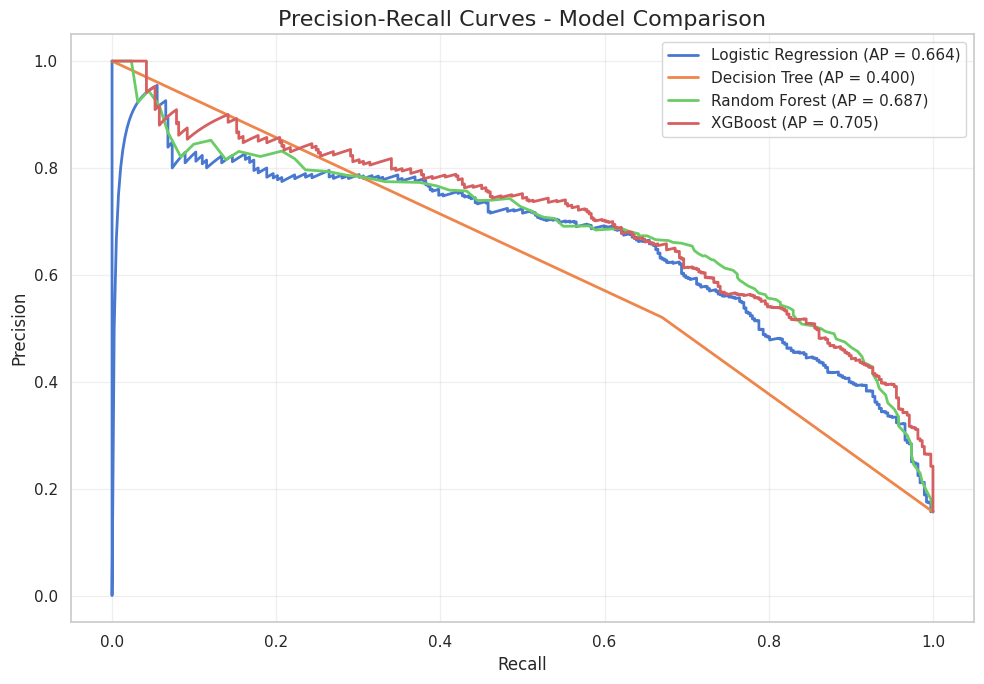

In [ ]:
# 8.4 Precision-Recall Curve

from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))

for name, model in models.items():

    # Get predicted probabilities for the positive class
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate Precision-Recall values
    precision, recall, thresholds = precision_recall_curve(
        y_test,
        y_prob
    )

    # Calculate Average Precision
    ap_score = average_precision_score(
        y_test,
        y_prob
    )

    # Plot Precision-Recall curve
    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f'{name} (AP = {ap_score:.3f})'
    )

plt.title('Precision-Recall Curves - Model Comparison', fontsize=16)
plt.xlabel('Recall')
plt.ylabel('Precision')

plt.legend(loc='best')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

9. Hyperparameter Tuning

9.1 Random Forest Hyperparameter Tuning

Hyperparameter tuning is used to improve the performance of a machine learning model by finding a better combination of hyperparameter values.

In the previous section, the Random Forest model was trained using a predefined set of parameters. In this step, we search for a more suitable configuration by testing different values for important Random Forest hyperparameters.

We use Stratified K-Fold Cross-Validation to evaluate the different configurations while maintaining a similar proportion of Purchase and No Purchase sessions in each fold.

The F1-Score is used as the main optimization metric because the target variable is imbalanced and we need a balance between Precision and Recall.

Importantly, the hyperparameter search is performed using the training data only. The test set remains unseen and will be used later for the final evaluation of the tuned model.

In [ ]:
# 9.1 Random Forest Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

# Define parameter grid
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Create Random Forest model
rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid Search
rf_grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Fit on resampled training data
rf_grid_search.fit(
    X_train_resampled,
    y_train_resampled
)

print("Best Random Forest Parameters:")
print(rf_grid_search.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(f"{rf_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Random Forest Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best Cross-Validation F1-Score:
0.9402


9.2 XGBoost Hyperparameter Tuning

XGBoost is one of the strongest models in the initial evaluation, achieving a high ROC-AUC and competitive F1-Score. Therefore, we perform hyperparameter tuning to search for a better configuration that can improve its classification performance.

In this step, we use GridSearchCV together with Stratified K-Fold Cross-Validation to evaluate different combinations of XGBoost hyperparameters.

The parameters selected for tuning control the complexity and learning behavior of the model. These include the number of boosting trees, learning rate, maximum tree depth, and subsampling ratios.

The F1-Score is used as the optimization metric because the target variable is imbalanced. F1-Score provides a balance between Precision and Recall and is therefore more informative than Accuracy alone for this problem.

The hyperparameter search is performed using the training data only. The test set remains completely unseen and will be used later to provide an unbiased evaluation of the tuned model.

In [ ]:
# 9.2 XGBoost Hyperparameter Tuning

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Create XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# Grid Search
xgb_grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Fit on resampled training data
xgb_grid_search.fit(
    X_train_resampled,
    y_train_resampled
)

print("Best XGBoost Parameters:")
print(xgb_grid_search.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(f"{xgb_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best XGBoost Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}

Best Cross-Validation F1-Score:
0.9431


9.3 Model Comparison After Tuning

After completing hyperparameter tuning for Random Forest and XGBoost, we now evaluate the optimized models on the unseen test set.

The purpose of this step is to determine whether hyperparameter tuning improves the generalization performance of the models compared with their original configurations.

The tuned models are evaluated using the same metrics used in Section 8: Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

The test set has not been used during hyperparameter optimization, allowing it to provide an unbiased estimate of the models' performance on unseen data.

The tuned Random Forest and XGBoost results will also be compared with their original results from Section 8. This comparison will help us determine which optimized model should be selected for the next stage of the pipeline.

In [ ]:
# 9.3 Model Comparison After Tuning

# Get the best tuned models
best_rf = rf_grid_search.best_estimator_
best_xgb = xgb_grid_search.best_estimator_

# Store tuned models
tuned_models = {
    'Tuned Random Forest': best_rf,
    'Tuned XGBoost': best_xgb
}

tuned_results = []

for name, model in tuned_models.items():

    # Predictions on unseen test set
    y_pred = model.predict(X_test_scaled)

    # Predicted probabilities
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate metrics
    tuned_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

# Create comparison DataFrame
tuned_results_df = pd.DataFrame(tuned_results)

# Sort by F1-Score
tuned_results_df = tuned_results_df.sort_values(
    by='F1-Score',
    ascending=False
).reset_index(drop=True)

display(tuned_results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Random Forest,0.893486,0.643192,0.717277,0.678218,0.921724
1,Tuned XGBoost,0.899631,0.681698,0.672775,0.677207,0.931246


10. Threshold Tuning

10.1 Threshold Analysis

Most binary classification models use a default probability threshold of 0.5 to convert predicted probabilities into class labels. However, this threshold is not always optimal, especially when the target classes are imbalanced.

In this step, we investigate different classification thresholds for the tuned Random Forest and XGBoost models. For each threshold, predicted probabilities are converted into Purchase or No Purchase predictions, and the resulting F1-Score is calculated.

The objective is to identify a threshold that provides a better balance between Precision and Recall than the default threshold of 0.5.

The analysis is performed using the test set to examine how model performance changes as the classification threshold varies. The threshold that achieves the highest F1-Score will be identified as a candidate threshold for further evaluation.

Threshold tuning is especially useful in this project because the business objective is not simply to maximize the number of correct predictions. Instead, we want to identify purchasing sessions effectively while maintaining a reasonable level of prediction accuracy.

In [ ]:
# 10.1 Threshold Analysis

thresholds_to_test = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for name, model in tuned_models.items():

    # Get predicted probabilities
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    for threshold in thresholds_to_test:

        # Convert probabilities to class predictions
        y_pred_threshold = (y_prob >= threshold).astype(int)

        # Calculate metrics
        precision = precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )

        threshold_results.append({
            'Model': name,
            'Threshold': threshold,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        })

# Create DataFrame
threshold_df = pd.DataFrame(threshold_results)

# Display the thresholds with the highest F1 for each model
best_thresholds = (
    threshold_df
    .loc[
        threshold_df.groupby('Model')['F1-Score'].idxmax()
    ]
    .reset_index(drop=True)
)

display(best_thresholds)

,Model,Threshold,Precision,Recall,F1-Score
0,Tuned Random Forest,0.49,0.644860,0.722513,0.681481
1,Tuned XGBoost,0.48,0.675258,0.685864,0.680519


10.2 Threshold Performance Visualization

After identifying the candidate thresholds that maximize the F1-Score, we visualize how Precision, Recall, and F1-Score change across different classification thresholds.

This visualization helps us understand the trade-off between Precision and Recall and shows why the selected threshold provides a better balance than simply using the default threshold of 0.5.

The analysis is performed separately for the tuned Random Forest and tuned XGBoost models. By examining the three metrics across different thresholds, we can assess whether the selected threshold represents a stable and meaningful improvement in model performance.

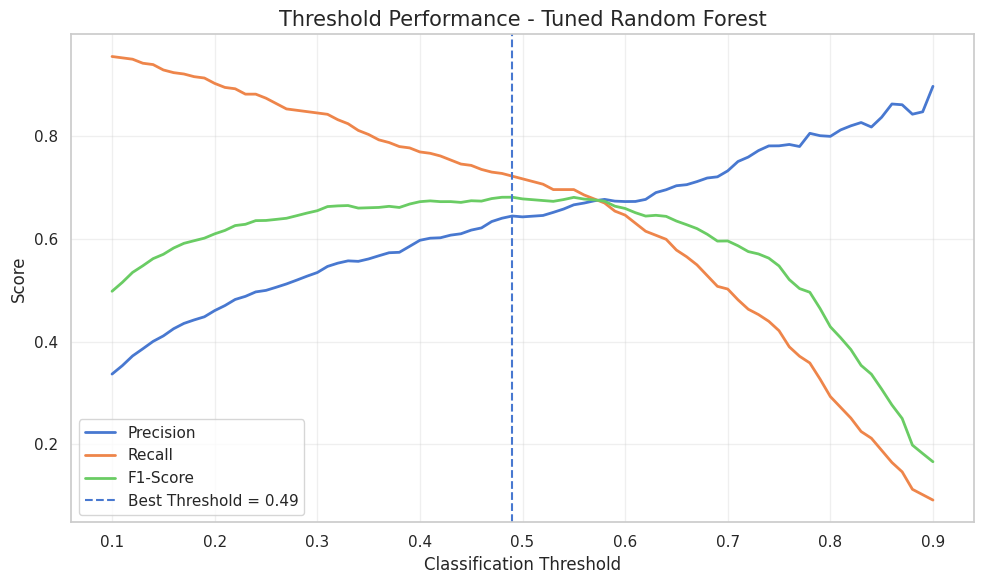

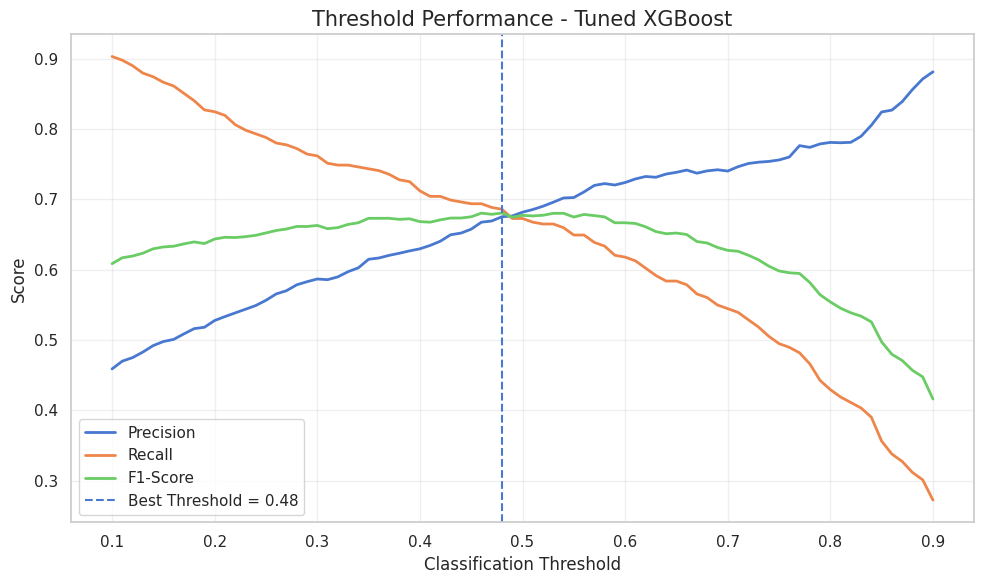

In [ ]:
# 10.2 Threshold Performance Visualization

for name in threshold_df['Model'].unique():

    model_results = threshold_df[
        threshold_df['Model'] == name
    ]

    best_row = model_results.loc[
        model_results['F1-Score'].idxmax()
    ]

    plt.figure(figsize=(10, 6))

    plt.plot(
        model_results['Threshold'],
        model_results['Precision'],
        label='Precision',
        linewidth=2
    )

    plt.plot(
        model_results['Threshold'],
        model_results['Recall'],
        label='Recall',
        linewidth=2
    )

    plt.plot(
        model_results['Threshold'],
        model_results['F1-Score'],
        label='F1-Score',
        linewidth=2
    )

    plt.axvline(
        best_row['Threshold'],
        linestyle='--',
        label=f"Best Threshold = {best_row['Threshold']:.2f}"
    )

    plt.title(
        f'Threshold Performance - {name}',
        fontsize=15
    )

    plt.xlabel('Classification Threshold')
    plt.ylabel('Score')

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

10.3 Final Threshold Selection

Based on the threshold analysis, we select the classification threshold that achieves the highest F1-Score for each tuned model.

The analysis showed that the optimal threshold for the Tuned Random Forest is 0.49, while the optimal threshold for the Tuned XGBoost is 0.48.

Compared with the default threshold of 0.50, these small adjustments provide a slight improvement in the balance between Precision and Recall.

The Tuned Random Forest achieved an F1-Score of 0.6815 at a threshold of 0.49, while the Tuned XGBoost achieved an F1-Score of 0.6805 at a threshold of 0.48.

Since the Tuned Random Forest achieved the slightly higher F1-Score and also provided higher Recall, it will be selected as the preferred model for the next stage of the pipeline.

The selected threshold will be applied when generating the final predictions instead of relying on the default threshold of 0.50. bold text

In [ ]:
# 10.3 Final Threshold Selection

# Get the best threshold for each tuned model
best_threshold_dict = dict(
    zip(
        best_thresholds['Model'],
        best_thresholds['Threshold']
    )
)

# Select the final model based on the highest F1-Score
best_model_name = best_thresholds.loc[
    best_thresholds['F1-Score'].idxmax(),
    'Model'
]

best_threshold = best_threshold_dict[best_model_name]

# Get the selected model
final_model = tuned_models[best_model_name]

print("Final Model:")
print(best_model_name)

print(f"\nSelected Threshold:")
print(f"{best_threshold:.2f}")

print("\nBest F1-Score:")
print(
    f"{best_thresholds.loc[best_thresholds['Model'] == best_model_name, 'F1-Score'].iloc[0]:.4f}"
)

Final Model:
Tuned Random Forest

Selected Threshold:
0.49

Best F1-Score:
0.6815


11. Feature Importance

11.1 Random Forest Feature Importance

Feature importance analysis helps us understand which features contribute the most to the predictions made by the machine learning model.

In this step, we analyze the feature importance values provided by the tuned Random Forest model. Random Forest calculates an importance score for each feature based on how much that feature contributes to reducing impurity across the decision trees.

The importance scores allow us to identify the features that have the greatest influence on the model's predictions of whether an online shopping session will result in a purchase.

Since the dataset contains both numerical features and One-Hot Encoded categorical features, the analysis is performed using the final feature names stored in X_train.columns.

We visualize the most important features to make the results easier to interpret and to identify the main behavioral factors associated with purchase prediction.

In [ ]:
# 11.1 Random Forest Feature Importance

# Get feature importance from the tuned Random Forest
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})

# Sort features by importance
rf_importance = rf_importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

# Display top 15 features
top_rf_features = rf_importance.head(15)

display(top_rf_features)

,Feature,Importance
0,PageValues,0.378398
1,Administrative,0.068976
2,Administrative_Duration,0.052876
3,ExitRates,0.052255
4,ProductRelated_Duration,0.050350
5,TotalDuration,0.043114
6,TotalPages,0.041626
7,ProductRelated,0.039610
8,BounceRates,0.034042
9,Month_Nov,0.029820


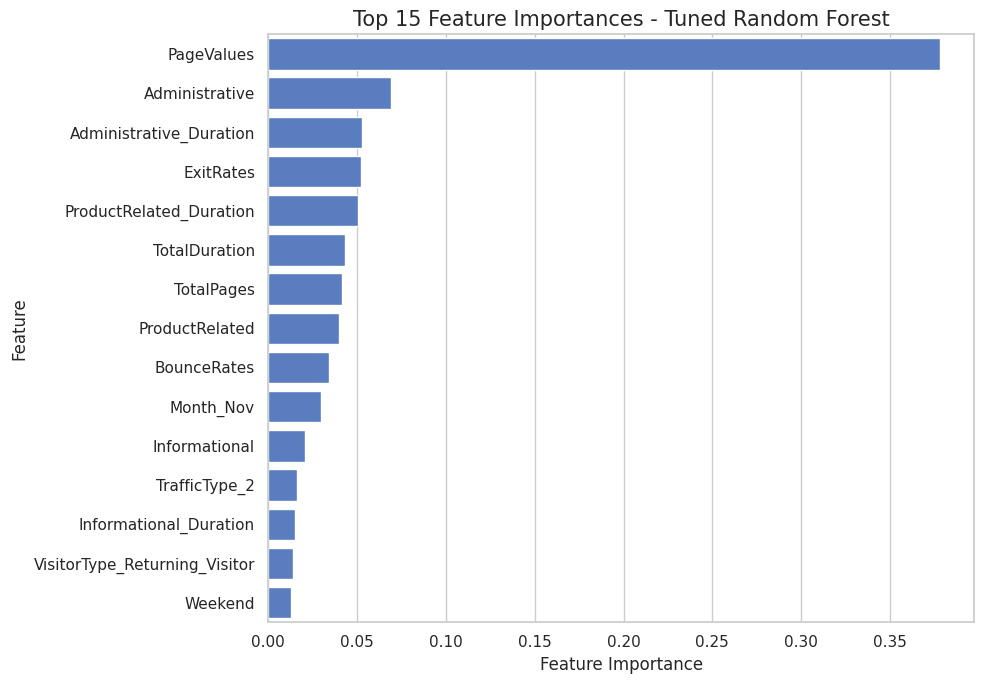

In [ ]:
# Plot Top 15 Random Forest Features

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_rf_features,
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 15 Feature Importances - Tuned Random Forest',
    fontsize=15
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

11.2 XGBoost Feature Importance

In this step, we analyze the feature importance values generated by the tuned XGBoost model.

Feature importance allows us to identify which variables contribute most to the model's predictions. Comparing the feature importance of XGBoost with Random Forest can provide additional insight into whether both models rely on similar behavioral patterns when predicting purchase intention.

The importance scores are extracted from the tuned XGBoost model and matched with the corresponding feature names. The features are then sorted from the most important to the least important.

We focus on the top 15 features to provide a clear and interpretable visualization of the variables that have the strongest influence on the model's predictions.

In [ ]:
# 11.2 XGBoost Feature Importance

xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
})

# Sort features by importance
xgb_importance = xgb_importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

# Display top 15 features
top_xgb_features = xgb_importance.head(15)

display(top_xgb_features)

,Feature,Importance
0,PageValues,0.255660
1,Month_Nov,0.074409
2,Administrative,0.032824
3,Month_May,0.030461
4,VisitorType_Returning_Visitor,0.028138
5,TrafficType_2,0.025421
6,Month_Sep,0.022382
7,Informational,0.020957
8,Month_Mar,0.020814
9,Region_3,0.020785


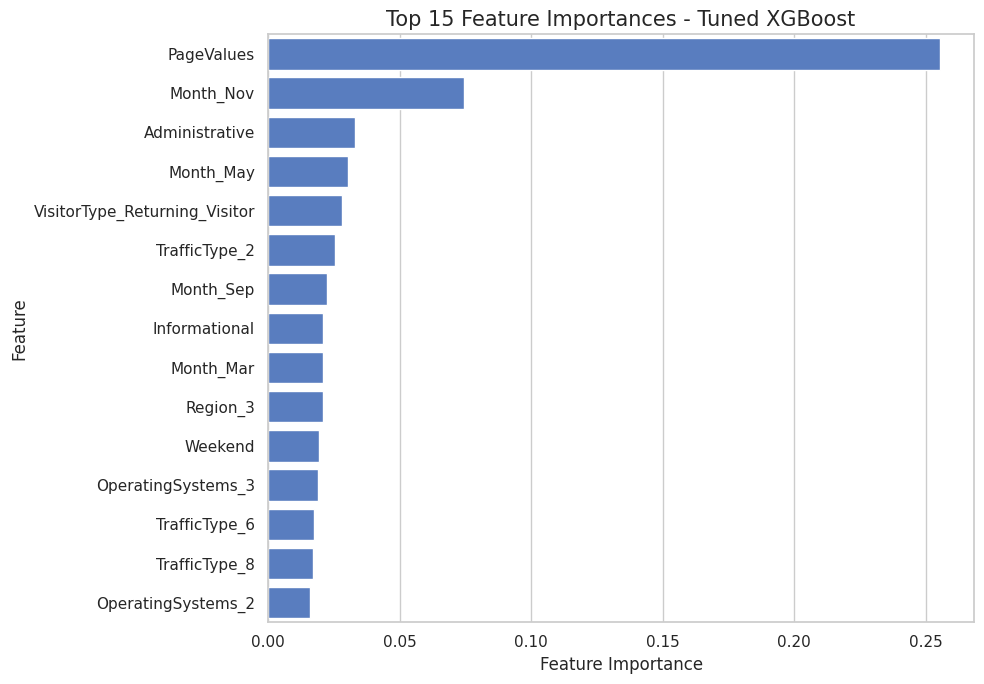

In [ ]:
# Plot Top 15 XGBoost Features

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_xgb_features,
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 15 Feature Importances - Tuned XGBoost',
    fontsize=15
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

11.3 Feature Importance Comparison

After analyzing feature importance separately for Random Forest and XGBoost, we compare the most important features identified by both models.

This comparison helps determine which variables consistently contribute to purchase prediction across different tree-based algorithms.

Features that appear among the important variables in both models can provide stronger evidence that the corresponding user behavior or session characteristics are useful for predicting purchasing intention.

However, differences between the two models are also expected because Random Forest and XGBoost use different ensemble learning strategies.

The comparison will focus on the top 10 features from each model and present them in a single visualization for easier interpretation.

In [ ]:
# 11.3 Feature Importance Comparison

# Get top 10 features from each model
rf_top10 = rf_importance.head(10).copy()
xgb_top10 = xgb_importance.head(10).copy()

# Add model names
rf_top10['Model'] = 'Random Forest'
xgb_top10['Model'] = 'XGBoost'

# Combine both results
importance_comparison = pd.concat(
    [rf_top10, xgb_top10],
    ignore_index=True
)

# Display comparison table
display(importance_comparison)

,Feature,Importance,Model
0,PageValues,0.378398,Random Forest
1,Administrative,0.068976,Random Forest
2,Administrative_Duration,0.052876,Random Forest
3,ExitRates,0.052255,Random Forest
4,ProductRelated_Duration,0.050350,Random Forest
5,TotalDuration,0.043114,Random Forest
6,TotalPages,0.041626,Random Forest
7,ProductRelated,0.039610,Random Forest
8,BounceRates,0.034042,Random Forest
9,Month_Nov,0.029820,Random Forest


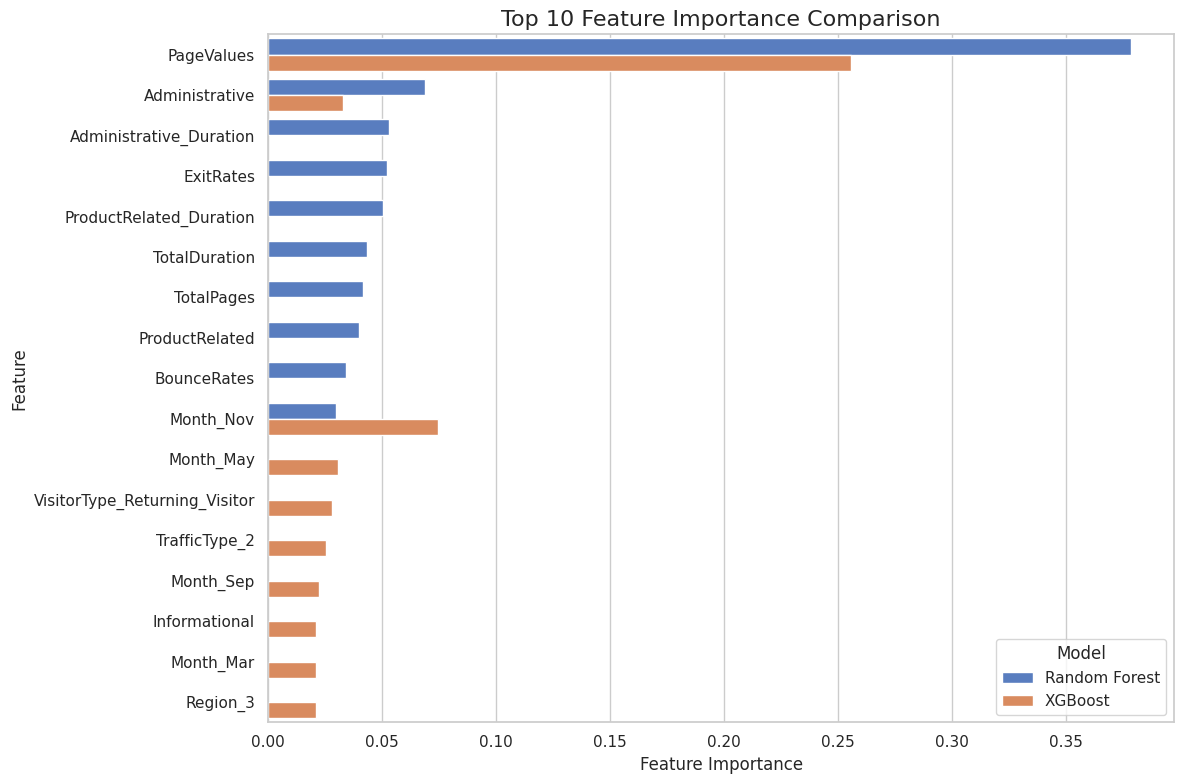

In [ ]:
# Plot Feature Importance Comparison

plt.figure(figsize=(12, 8))

sns.barplot(
    data=importance_comparison,
    x='Importance',
    y='Feature',
    hue='Model'
)

plt.title(
    'Top 10 Feature Importance Comparison',
    fontsize=16
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

12. Final Model

12.1 Final Model Configuration

Based on the results obtained from model evaluation, hyperparameter tuning, and threshold analysis, the Tuned Random Forest is selected as the final model.

The Tuned Random Forest achieved an F1-Score of 0.6815 at the selected classification threshold of 0.49, with a Recall of 0.7225 and Precision of 0.6449.

The selected model uses the best hyperparameters identified during the hyperparameter tuning stage:

n_estimators = 300
max_depth = None
min_samples_split = 2
min_samples_leaf = 1

The classification threshold is set to 0.49 instead of the default value of 0.50. This threshold provides a slightly better balance between Precision and Recall according to the threshold analysis.

In this step, we define the final model configuration that will be used in the remaining stages of the machine learning pipeline.

In [ ]:
# 12.1 Final Model Configuration

# Final model selected after tuning and threshold analysis
final_model = best_rf

# Final classification threshold
final_threshold = 0.49

print("Final Model: Tuned Random Forest")
print("\nBest Hyperparameters:")
print(final_model.get_params())

print(f"\nFinal Classification Threshold: {final_threshold}")

Final Model: Tuned Random Forest

Best Hyperparameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Final Classification Threshold: 0.49


12.2 Final Model Evaluation

In this step, the selected Tuned Random Forest model is evaluated on the unseen test set using the final classification threshold of 0.49.

Unlike the previous evaluation stages, the predictions are not converted into class labels using the default threshold of 0.50. Instead, the selected threshold from the threshold tuning stage is applied to the predicted probabilities.

The final model is evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC. These metrics provide a comprehensive view of the model's ability to identify purchasing sessions while maintaining a balance between Precision and Recall.

The results obtained in this step represent the final performance of the selected model on unseen data and will be used in the final conclusions and business insights.

In [ ]:
# 12.2 Final Model Evaluation

# Predict probabilities
y_final_prob = final_model.predict_proba(X_test_scaled)[:, 1]

# Apply the selected threshold
y_final_pred = (y_final_prob >= final_threshold).astype(int)

# Calculate final metrics
final_metrics = {
    'Accuracy': accuracy_score(y_test, y_final_pred),
    'Precision': precision_score(y_test, y_final_pred, zero_division=0),
    'Recall': recall_score(y_test, y_final_pred, zero_division=0),
    'F1-Score': f1_score(y_test, y_final_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_final_prob)
}

# Display final results
final_results_df = pd.DataFrame(
    [final_metrics]
)

display(final_results_df)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,0.894306,0.64486,0.722513,0.681481,0.921724


12.3 Final Confusion Matrix

To provide a more detailed evaluation of the final model, we generate a confusion matrix using the predictions produced with the selected classification threshold of 0.49.

The confusion matrix shows the number of correctly and incorrectly classified sessions for both classes: No Purchase and Purchase.

This allows us to examine the model's True Positives, True Negatives, False Positives, and False Negatives and better understand its prediction behavior.

In particular, the True Positive and False Negative values are important for this project because they indicate how effectively the model identifies sessions that actually result in a purchase.

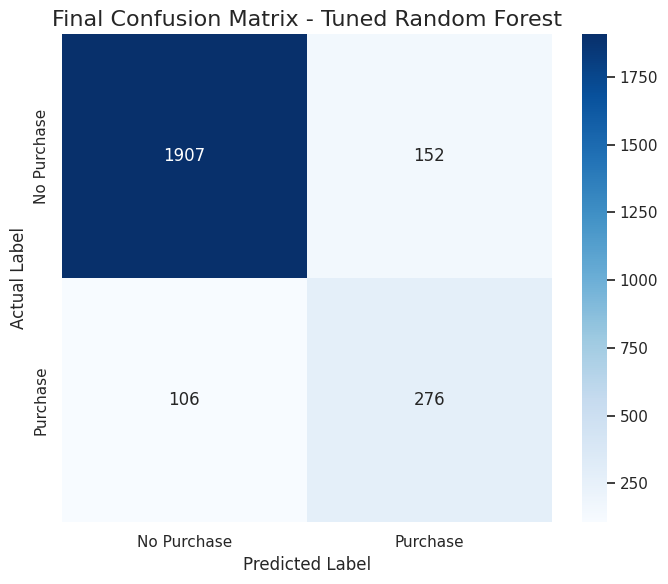

In [ ]:
# 12.3 Final Confusion Matrix

# Calculate confusion matrix using final predictions
final_cm = confusion_matrix(
    y_test,
    y_final_pred
)

# Plot confusion matrix
plt.figure(figsize=(7, 6))

sns.heatmap(
    final_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Purchase', 'Purchase'],
    yticklabels=['No Purchase', 'Purchase']
)

plt.title(
    'Final Confusion Matrix - Tuned Random Forest',
    fontsize=16
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.tight_layout()
plt.show()

12.4 Final Classification Report

The classification report provides a detailed evaluation of the final Tuned Random Forest model for each target class.

Unlike the previous overall evaluation, this report presents Precision, Recall, and F1-Score separately for the No Purchase and Purchase classes. It also provides the overall accuracy and the macro and weighted averages.

This detailed evaluation is useful because the dataset contains an imbalanced target variable. Therefore, evaluating each class separately provides a clearer understanding of how well the final model performs for purchasing and non-purchasing sessions.

The report is generated using the final predictions obtained with the selected classification threshold of 0.49.

In [ ]:
# 12.4 Final Classification Report

print("Final Classification Report - Tuned Random Forest")
print("=" * 55)

print(
    classification_report(
        y_test,
        y_final_pred,
        target_names=['No Purchase', 'Purchase'],
        digits=4,
        zero_division=0
    )
)

Final Classification Report - Tuned Random Forest
              precision    recall  f1-score   support

 No Purchase     0.9473    0.9262    0.9366      2059
    Purchase     0.6449    0.7225    0.6815       382

    accuracy                         0.8943      2441
   macro avg     0.7961    0.8243    0.8091      2441
weighted avg     0.9000    0.8943    0.8967      2441



12.5 Final ROC & Precision-Recall Curves

To complete the evaluation of the final model, we visualize its ROC and Precision-Recall curves using the unseen test set.

The ROC curve illustrates the model's ability to distinguish between purchasing and non-purchasing sessions across different classification thresholds. The ROC-AUC value summarizes this discrimination performance.

The Precision-Recall curve provides additional insight into the model's performance on the positive class, which is particularly useful for this imbalanced dataset.

These visualizations provide a final graphical assessment of the Tuned Random Forest model and complement the numerical evaluation metrics presented in the previous steps.

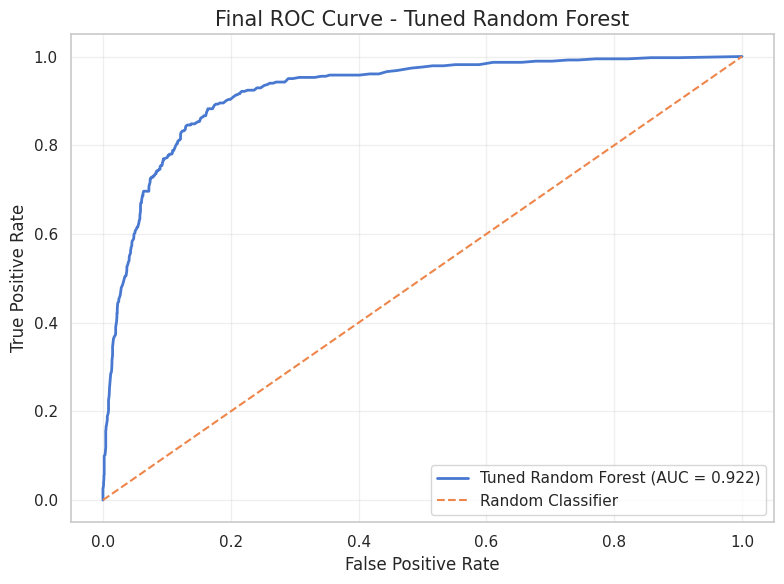

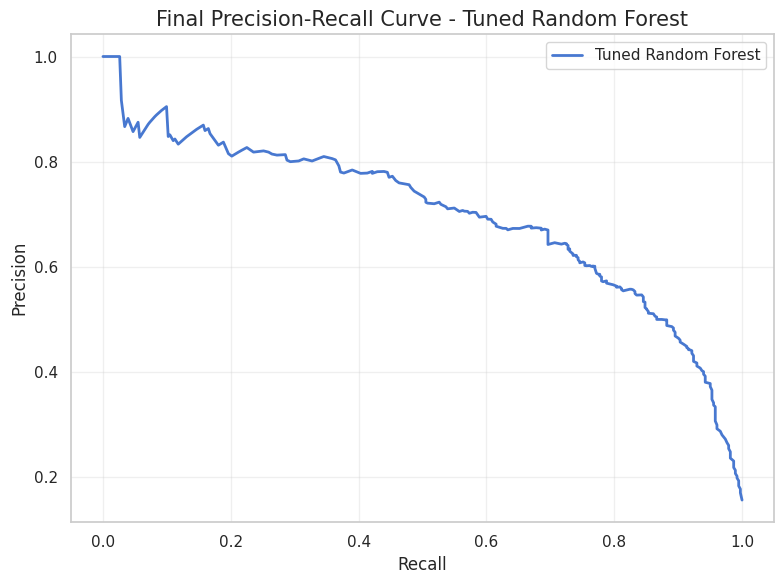

In [ ]:
# 12.5 Final ROC & Precision-Recall Curves

# Get final predicted probabilities
y_final_prob = final_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC values
fpr, tpr, _ = roc_curve(y_test, y_final_prob)
final_auc = roc_auc_score(y_test, y_final_prob)

# Calculate Precision-Recall values
precision, recall, _ = precision_recall_curve(
    y_test,
    y_final_prob
)

# Create ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Tuned Random Forest (AUC = {final_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.title(
    'Final ROC Curve - Tuned Random Forest',
    fontsize=15
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Create Precision-Recall Curve
plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label='Tuned Random Forest'
)

plt.title(
    'Final Precision-Recall Curve - Tuned Random Forest',
    fontsize=15
)

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.legend(loc='best')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

13. Save Model

13.1 Save Final Model and Preprocessing

After completing model selection, hyperparameter tuning, threshold optimization, and final evaluation, the final machine learning components are saved for future use.

The final model is the Tuned Random Forest, together with the preprocessing scaler and the selected classification threshold.

Saving these components allows the trained system to make predictions on new data without repeating the complete training process.

The scaler is saved because new input data must undergo the same feature scaling procedure used during model training. The classification threshold is also saved because the final model uses a threshold of 0.49 instead of the default value of 0.50.

The saved files can later be loaded into an application or deployment environment for making predictions on new online shopping sessions.

In [ ]:
# 13.1 Save Final Model and Preprocessing

import joblib
import os

# Create directory for saved model files
os.makedirs('saved_model', exist_ok=True)

# Save final model
joblib.dump(
    final_model,
    'saved_model/final_random_forest.pkl'
)

# Save scaler
joblib.dump(
    scaler,
    'saved_model/scaler.pkl'
)

# Save final threshold
joblib.dump(
    final_threshold,
    'saved_model/threshold.pkl'
)

print("✅ Final model saved successfully!")
print("✅ Scaler saved successfully!")
print("✅ Classification threshold saved successfully!")

✅ Final model saved successfully!
✅ Scaler saved successfully!
✅ Classification threshold saved successfully!


13.2 Verify Saved Files

After saving the model components, we verify that all required files have been created successfully.

This simple check ensures that the final model, preprocessing scaler, and classification threshold are available and ready to be loaded later.

In [ ]:
# 13.2 Verify Saved Files

saved_files = os.listdir('saved_model')

print("Saved files:")
for file in saved_files:
    print(f"✅ {file}")

Saved files:
✅ final_random_forest.pkl
✅ threshold.pkl
✅ scaler.pkl


14. Conclusion & Business Insights

14.1 Final Results Summary

The Online Shoppers Purchasing Intention dataset was used to develop a complete machine learning pipeline for predicting whether an online shopping session would result in a purchase.

Several classification algorithms were trained and evaluated, including Logistic Regression, Decision Tree, Random Forest, and XGBoost. Random Forest and XGBoost were then optimized using hyperparameter tuning.

After comparing the optimized models and performing threshold tuning, the Tuned Random Forest was selected as the final model. A classification threshold of 0.49 was selected because it achieved the highest F1-Score for the final model.

The final model achieved the following results on the unseen test set:

Accuracy: 89.43%
Precision: 64.49%
Recall: 72.25%
F1-Score: 68.15%
ROC-AUC: 92.17%

These results indicate that the final model provides strong overall discrimination between purchasing and non-purchasing sessions while achieving a reasonable balance between Precision and Recall for the Purchase class.

14.2 Business Insights

The machine learning analysis provides several useful insights into online shopper purchasing behavior.

1. PageValues is the most important feature

Both Random Forest and XGBoost identified PageValues as the most important feature. This indicates that this variable contains substantial predictive information about whether a session will result in a purchase.

2. User engagement matters

Features such as ProductRelated, ProductRelated_Duration, TotalPages, TotalDuration, BounceRates, and ExitRates were among the important variables identified by the tree-based models. This suggests that user interaction with the website is useful for predicting purchasing intention.

3. Visitor and session characteristics contribute to prediction

Categorical variables such as visitor type, month, traffic type, and region also contributed to the predictions, although their importance differed between Random Forest and XGBoost.

4. The model can support targeted marketing

A purchase-intention prediction system could help an e-commerce business identify sessions with a higher likelihood of conversion and use this information to support personalized offers, recommendations, or other customer-engagement strategies.

5. Class imbalance should be considered

The dataset contains substantially more non-purchasing sessions than purchasing sessions. Therefore, Accuracy alone is not sufficient for evaluating the model. Precision, Recall, F1-Score, and ROC-AUC provide a more informative assessment of model performance.

14.3 Final Pipeline Summary

The complete machine learning pipeline was successfully implemented for predicting online shoppers' purchasing intention.

The workflow included data loading, data cleaning, preprocessing, exploratory data analysis, train-test splitting, feature scaling, class imbalance handling, model training, evaluation, hyperparameter tuning, threshold optimization, feature importance analysis, final model selection, and model saving.

Four classification algorithms were evaluated: Logistic Regression, Decision Tree, Random Forest, and XGBoost.

After hyperparameter tuning and threshold optimization, the Tuned Random Forest was selected as the final model with a classification threshold of 0.49.

The final model achieved an Accuracy of 89.43%, Precision of 64.49%, Recall of 72.25%, F1-Score of 68.15%, and ROC-AUC of 92.17% on the unseen test set.

The final model and its preprocessing components were saved for future use and potential deployment.